# **Rent Analysis in Seoul** 

## **Introduction**

The aim of this analysis is to describe the Seoul rental market (Jeonse and Monthly rent contracts, 2022–2025) and to identify the factors associated with rental prices: district, building type, size, floor, building age and lease type.

This analysis uses data from Seoul Open Data Plaza (https://data.seoul.go.kr/#), which include rental prices, housing types and other relevant factors.

The source dataset is:
- Seoul Real Estate Jeonse and Monthly Rent Price Information (https://data.seoul.go.kr/dataList/OA-21276/S/1/datasetView.do)

The dataset combines the 2022–2025 yearly files and contains 400,000 rows, sampled so that each year contributes about 100,000 records.

The CSV was built by merging the yearly files, sampling about 100,000 records per year, romanizing the district and neighborhood names, and inferring `lease_type` from `monthly_rent == 0` in 2022, 2024 and 2025 (2023 keeps the original value). The preparation script is not included in this repository.

The information about the columns from the dataset is the following:
<center>

|Column Name|Column Description|Notes|
|:---|:-------|:-------|
|`registration_year`|Year the contract was registered (file year).|Not the contract year; use `contract_date` for that. A few rows are 2021.|
|`district_code`|Code of the Seoul district (gu).|5 digits. See Lookup_Dongs.|
|`district_name`|District name in English.|Recovered from `district_code` (25 districts).|
|`legal_dong_code`|Code of the legal neighborhood (dong) within the district.|Only unique together with `district_code`.|
|`legal_dong_name`|Neighborhood name, romanized.|Automatic romanization; Korean original in Lookup_Dongs. Blank for a few unmapped codes.|
|`lot_type_code`|Type of lot number: 1, 2 or 3.|Blank for detached / multi-household houses (no lot number in source).|
|`lot_type`|Land lot / Mountain lot / Block lot.|From `lot_type_code`.|
|`main_lot_number`|Main lot number (jibun) of the address.||
|`sub_lot_number`|Sub lot number (jibun) of the address.|0 = none.|
|`floor`|Floor of the unit.|Negative = basement. Blank if not reported.|
|`contract_date`|Date the contract was signed.|Format yyyy-mm-dd.|
|`lease_type`|Jeonse (deposit only) or Monthly rent.|2023: original value. Other years: inferred (monthly rent = 0 -> Jeonse); matches the original in 99.96% of 2023 rows.|
|`leased_area_sqm`|Leased area in square meters (m2).||
|`deposit_10k_krw`|Deposit, in 10,000 KRW.|Example: 16000 = 160,000,000 KRW.|
|`monthly_rent_10k_krw`|Monthly rent, in 10,000 KRW.|0 for Jeonse.|
|`building_name`|Building name (Korean).|Only available for 2023 rows; unrecoverable in 2022/2024/2025 files. Blank when unnamed.|
|`year_built`|Year the building was built.||
|`building_type`|Apartment / Officetel / Row house-Villa / Detached-Multi-household house.|Recovered in all years.|
|`contract_period`|Lease term as YY.MM~YY.MM.|Example: 22.01~24.01 = Jan 2022 to Jan 2024.|
|`contract_type`|New contract or Renewal.|Blank = not specified in source.|
|`renewal_right_used`|Yes if the tenant used the renewal-request right.|Blank = no / not reported.|
|`previous_deposit_10k_krw`|Deposit of the previous contract (renewals), in 10,000 KRW.||
|`previous_monthly_rent_10k_krw`|Monthly rent of the previous contract (renewals), in 10,000 KRW.||

</center>

## **1: Imports** 

These are the libraries used in this analysis:

In [1]:
# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

## **2: Read dataset** 

The method **.read_csv** from the library **pandas** reads a CSV file and returns a DataFrame. It is used to load the dataset into a pandas DataFrame for further analysis.

The syntax is:
pd.read_csv('file_path')

In this analysis, the dataset is loaded from the relative path `'data/Seoul_Rentals_2022_2025.csv'` and stored in the variable `df`.

In [2]:
df = pd.read_csv('data/Seoul_Rentals_2022_2025.csv')

## **3: Data exploration**

The first rows give a quick view of the dataset structure and of possible issues.

In [3]:
df.head(10)

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,main_lot_number,sub_lot_number,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,building_name,year_built,building_type,contract_period,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw
0,2022,11110,Jongno-gu,17500,Sungin-dong,1.0,Land lot,204.0,11.0,8.0,2022-01-01,Jeonse (deposit only),"78,75",24000,0,NaN,1979.0,Apartment,22.01~23.12,Renewal,Yes,23000.0,NaN
1,2022,11170,Yongsan-gu,10200,Yongsan-dong 2-ga,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,30,500,40,NaN,1985.0,Detached / Multi-household house,22.01~24.01,New,NaN,0.0,0.0
2,2022,11170,Yongsan-gu,11100,Cheongpa-dong 3-ga,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,"18,5",1000,40,NaN,1970.0,Detached / Multi-household house,22.01~23.12,New,NaN,0.0,0.0
3,2022,11170,Yongsan-gu,12200,Munbae-dong,1.0,Land lot,24.0,4.0,13.0,2022-01-01,Monthly rent,"17,46",17500,10,NaN,2013.0,Officetel,22.01~22.12,Renewal,NaN,17500.0,0.0
4,2022,11200,Seongdong-gu,10800,Eungbong-dong,1.0,Land lot,265.0,24.0,1.0,2022-01-01,Jeonse (deposit only),"38,19",11000,0,NaN,1992.0,Row house / Villa (multi-unit),NaN,NaN,NaN,NaN,NaN
5,2022,11215,Gwangjin-gu,10100,Junggok-dong,1.0,Land lot,150.0,323.0,1.0,2022-01-01,Monthly rent,"74,49",10000,60,NaN,1997.0,Row house / Villa (multi-unit),22.02~24.02,New,NaN,0.0,0.0
6,2022,11215,Gwangjin-gu,10100,Junggok-dong,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,"23,1",500,30,NaN,1997.0,Detached / Multi-household house,NaN,NaN,NaN,NaN,NaN
7,2022,11215,Gwangjin-gu,10700,Hwayang-dong,1.0,Land lot,111.0,12.0,8.0,2022-01-01,Monthly rent,"16,88",1000,80,NaN,2021.0,Officetel,22.01~23.01,New,NaN,0.0,0.0
8,2022,11215,Gwangjin-gu,10900,Gunja-dong,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,22,1000,47,NaN,2008.0,Detached / Multi-household house,22.01~24.01,New,NaN,0.0,0.0
9,2022,11230,Dongdaemun-gu,10600,Jangan-dong,1.0,Land lot,309.0,7.0,12.0,2022-01-01,Jeonse (deposit only),"54,56",10000,0,NaN,2021.0,Apartment,22.01~24.01,New,NaN,0.0,NaN


`df.shape` returns the number of rows and columns.

In [4]:
df.shape

(400000, 23)

`df.columns` lists the column names.

In [5]:
df.columns

Index(['registration_year', 'district_code', 'district_name',
       'legal_dong_code', 'legal_dong_name', 'lot_type_code', 'lot_type',
       'main_lot_number', 'sub_lot_number', 'floor', 'contract_date',
       'lease_type', 'leased_area_sqm', 'deposit_10k_krw',
       'monthly_rent_10k_krw', 'building_name', 'year_built', 'building_type',
       'contract_period', 'contract_type', 'renewal_right_used',
       'previous_deposit_10k_krw', 'previous_monthly_rent_10k_krw'],
      dtype='str')

`df.info()` shows the non-null count and data type of each column.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   registration_year              400000 non-null  int64  
 1   district_code                  400000 non-null  int64  
 2   district_name                  400000 non-null  str    
 3   legal_dong_code                400000 non-null  int64  
 4   legal_dong_name                399988 non-null  str    
 5   lot_type_code                  299849 non-null  float64
 6   lot_type                       299849 non-null  str    
 7   main_lot_number                299976 non-null  float64
 8   sub_lot_number                 299976 non-null  float64
 9   floor                          299870 non-null  float64
 10  contract_date                  400000 non-null  str    
 11  lease_type                     400000 non-null  str    
 12  leased_area_sqm                400000 non

`df.describe()` summarizes the numeric columns (count, mean, standard deviation, quartiles, minimum and maximum).

In [7]:
df.describe()

,registration_year,district_code,legal_dong_code,lot_type_code,main_lot_number,sub_lot_number,floor,deposit_10k_krw,monthly_rent_10k_krw,year_built,previous_deposit_10k_krw,previous_monthly_rent_10k_krw
count,400000.000000,400000.000000,400000.000000,299849.000000,299976.000000,299976.000000,299870.000000,400000.000000,400000.000000,387350.000000,2.169010e+05,1.069690e+05
mean,2023.500047,11473.243000,10941.825750,1.001998,518.486422,19.689475,7.528572,22838.000328,38.489715,2005.419246,1.118895e+06,1.831622e+03
std,1.118013,182.658818,1242.499795,0.059170,519.926969,89.991567,5.930113,28579.681414,65.651234,16.042567,2.628782e+07,4.933894e+04
min,2021.000000,11110.000000,10100.000000,1.000000,0.000000,0.000000,-4.000000,0.000000,0.000000,1006.000000,0.000000e+00,0.000000e+00
25%,2023.000000,11305.000000,10200.000000,1.000000,140.000000,0.000000,3.000000,2636.750000,0.000000,1995.000000,0.000000e+00,0.000000e+00
50%,2023.500000,11500.000000,10600.000000,1.000000,413.000000,1.000000,6.000000,14000.000000,15.000000,2007.000000,0.000000e+00,0.000000e+00
75%,2024.250000,11620.000000,11000.000000,1.000000,742.000000,11.000000,11.000000,30500.000000,56.000000,2017.000000,2.000000e+04,2.500000e+01
max,2025.000000,11740.000000,18700.000000,3.000000,4975.000000,4143.000000,302.000000,810000.000000,4000.000000,7811.000000,2.200000e+09,4.280000e+06


### **Check for missing values**

`df.isna().sum()` counts the missing values per column.

In [8]:
df.isna().sum()

registration_year                     0
district_code                         0
district_name                         0
legal_dong_code                       0
legal_dong_name                      12
lot_type_code                    100151
lot_type                         100151
main_lot_number                  100024
sub_lot_number                   100024
floor                            100130
contract_date                         0
lease_type                            0
leased_area_sqm                       0
deposit_10k_krw                       0
monthly_rent_10k_krw                  0
building_name                    309247
year_built                        12650
building_type                         0
contract_period                   54099
contract_type                     51380
renewal_right_used               363931
previous_deposit_10k_krw         183099
previous_monthly_rent_10k_krw    293031
dtype: int64

### **Check duplicates**

`df.duplicated().sum()` counts the fully duplicated rows.

In [9]:
df.duplicated().sum()

np.int64(10)

In [10]:
df[df.duplicated()]

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,main_lot_number,sub_lot_number,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,building_name,year_built,building_type,contract_period,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw
210303,2024,11410,Seodaemun-gu,11700,Yeonhui-dong,NaN,NaN,NaN,NaN,NaN,2024-01-22,Monthly rent,"17,5",500,35,NaN,NaN,Detached / Multi-household house,24.02~25.02,New,NaN,NaN,NaN
210875,2024,11215,Gwangjin-gu,10400,Gwangjang-dong,NaN,NaN,NaN,NaN,NaN,2024-01-24,Monthly rent,20,500,40,NaN,NaN,Detached / Multi-household house,24.02~26.02,New,NaN,NaN,NaN
229130,2024,11590,Dongjak-gu,10500,Heukseok-dong,1.0,Land lot,341.0,0.0,3.0,2024-03-25,Jeonse (deposit only),"84,91",100000,0,NaN,2019.0,Apartment,24.04~26.02,New,NaN,NaN,NaN
305752,2025,11230,Dongdaemun-gu,10500,Dapsipri-dong,1.0,Land lot,66.0,112.0,3.0,2025-01-12,Jeonse (deposit only),"82,31",50000,0,NaN,2024.0,Officetel,25.02~27.02,New,NaN,NaN,NaN
307559,2025,11200,Seongdong-gu,11500,Seongsu-dong 2-ga,1.0,Land lot,843.0,0.0,9.0,2025-01-18,Monthly rent,"57,49",10000,300,NaN,2009.0,Apartment,25.02~27.02,New,NaN,NaN,NaN
320234,2025,11230,Dongdaemun-gu,10500,Dapsipri-dong,1.0,Land lot,66.0,112.0,5.0,2025-02-28,Monthly rent,"82,31",20000,165,NaN,2024.0,Officetel,25.03~27.03,New,NaN,NaN,NaN
365567,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,32.0,2025-08-10,Jeonse (deposit only),"84,981",80000,0,NaN,2023.0,Apartment,25.10~27.10,New,NaN,NaN,NaN
366596,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,41.0,2025-08-14,Jeonse (deposit only),"84,983",68000,0,NaN,2023.0,Apartment,25.09~25.11,Renewal,NaN,68000.0,NaN
368382,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,7.0,2025-08-21,Jeonse (deposit only),"84,993",63000,0,NaN,2023.0,Apartment,25.09~27.09,Renewal,Yes,60000.0,NaN
370068,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,46.0,2025-08-27,Monthly rent,"84,981",33900,180,NaN,2023.0,Apartment,25.10~27.10,Renewal,NaN,30000.0,180.0


### **Check categorical columns**

`value_counts()` returns the frequency of each unique value of a column. It is applied below to `lease_type`, `registration_year` and `building_type`.

In [11]:
df['lease_type'].value_counts()

lease_type
Monthly rent             219690
Jeonse (deposit only)    180310
Name: count, dtype: int64

In [12]:
df['registration_year'].value_counts()

registration_year
2023    100028
2024    100000
2025    100000
2022     99963
2021         9
Name: count, dtype: int64

In [13]:
df['building_type'].value_counts()

building_type
Apartment                           162006
Detached / Multi-household house    100130
Row house / Villa (multi-unit)       86481
Officetel                            51383
Name: count, dtype: int64

## **4: Data cleaning**

Let's revise more columns to clean the data...

`df` has missing values in several columns. A copy (`df_copy`) is cleaned in the following order:

1. Duplicate rows are removed first, while `building_name`, `main_lot_number` and `sub_lot_number` are still present. Dropping those columns beforehand would turn distinct rows into false duplicates. The number of rows dropped is printed.
2. `building_name` (only available for 2023 rows) and the lot numbers are dropped.
3. Missing categorical values are filled with explicit labels (`Unknown`, `No lot type`, `Not specified`, `No/Not reported`), and `floor_reported` flags whether the floor was reported.
4. `contract_period` is split into `contract_start` and `contract_end`. Rows with a missing period are **kept** (both dates are `NaT`), because the diagnostic below shows that the missing values are not random.
5. Rows with a missing `year_built` are dropped, since building age is a key variable.

In [14]:
missing_period = df['contract_period'].isna()
print(f"Missing contract_period: {missing_period.sum():,} rows ({missing_period.mean() * 100:.2f}% of df)")

for col in ['registration_year', 'building_type']:
    summary = df.groupby(col)['contract_period'].agg(rows='size', missing=lambda s: s.isna().sum())
    summary['missing_pct'] = (summary['missing'] / summary['rows'] * 100).round(2)
    display(summary)

Missing contract_period: 54,099 rows (13.52% of df)


,rows,missing,missing_pct
registration_year,,,
2021,9,5,55.56
2022,99963,27288,27.30
2023,100028,19413,19.41
2024,100000,4732,4.73
2025,100000,2661,2.66


,rows,missing,missing_pct
building_type,,,
Apartment,162006,23805,14.69
Detached / Multi-household house,100130,17559,17.54
Officetel,51383,3874,7.54
Row house / Villa (multi-unit),86481,8861,10.25


**Finding.** 54,099 rows (13.52% of `df`) have no `contract_period`, and the missing share is far from uniform. It falls from 27.30% in 2022 and 19.41% in 2023 to 4.73% in 2024 and 2.66% in 2025, and it is higher for Detached / Multi-household houses (17.54%) and Apartments (14.69%) than for Row houses / Villas (10.25%) and Officetels (7.54%). Dropping these rows would remove a non-random part of the sample (mostly the early years and detached houses), so they are kept. Time analysis uses `contract_date`, not `contract_start` or `contract_end`.

In [15]:
df_copy = df.copy()

# Duplicates are removed first, while building_name and the lot numbers are still present
rows_before = len(df_copy)
df_copy = df_copy.drop_duplicates()
print(f"Duplicate rows dropped: {rows_before - len(df_copy):,}")

df_copy['legal_dong_name'] = df_copy['legal_dong_name'].fillna('Unknown')
df_copy = df_copy.drop(['building_name', 'main_lot_number', 'sub_lot_number'], axis=1)
df_copy['lot_type_code'] = df_copy['lot_type_code'].fillna(0.0)
df_copy['lot_type'] = df_copy['lot_type'].fillna('No lot type')
df_copy['floor_reported'] = df_copy['floor'].notna()
df_copy['contract_type'] = df_copy['contract_type'].fillna('Not specified')
df_copy['renewal_right_used'] = df_copy['renewal_right_used'].fillna('No/Not reported')

#Critical columns
df_copy = df_copy.dropna(subset=['year_built'])

#Divide the contract_period into two separate columns: contract_start and contract_end
# (NaT where the period is missing)
periods = df_copy['contract_period'].str.split('~', expand=True)

pos = df_copy.columns.get_loc('contract_period') + 1

df_copy.insert(pos, 'contract_start', pd.to_datetime(periods[0], format='%y.%m', errors='coerce'))
df_copy.insert(pos + 1, 'contract_end', pd.to_datetime(periods[1], format='%y.%m', errors='coerce'))

df_copy.head(10)

Duplicate rows dropped: 10


,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,year_built,building_type,contract_period,contract_start,contract_end,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw,floor_reported
0,2022,11110,Jongno-gu,17500,Sungin-dong,1.0,Land lot,8.0,2022-01-01,Jeonse (deposit only),"78,75",24000,0,1979.0,Apartment,22.01~23.12,2022-01-01,2023-12-01,Renewal,Yes,23000.0,NaN,True
1,2022,11170,Yongsan-gu,10200,Yongsan-dong 2-ga,0.0,No lot type,NaN,2022-01-01,Monthly rent,30,500,40,1985.0,Detached / Multi-household house,22.01~24.01,2022-01-01,2024-01-01,New,No/Not reported,0.0,0.0,False
2,2022,11170,Yongsan-gu,11100,Cheongpa-dong 3-ga,0.0,No lot type,NaN,2022-01-01,Monthly rent,"18,5",1000,40,1970.0,Detached / Multi-household house,22.01~23.12,2022-01-01,2023-12-01,New,No/Not reported,0.0,0.0,False
3,2022,11170,Yongsan-gu,12200,Munbae-dong,1.0,Land lot,13.0,2022-01-01,Monthly rent,"17,46",17500,10,2013.0,Officetel,22.01~22.12,2022-01-01,2022-12-01,Renewal,No/Not reported,17500.0,0.0,True
4,2022,11200,Seongdong-gu,10800,Eungbong-dong,1.0,Land lot,1.0,2022-01-01,Jeonse (deposit only),"38,19",11000,0,1992.0,Row house / Villa (multi-unit),NaN,NaT,NaT,Not specified,No/Not reported,NaN,NaN,True
5,2022,11215,Gwangjin-gu,10100,Junggok-dong,1.0,Land lot,1.0,2022-01-01,Monthly rent,"74,49",10000,60,1997.0,Row house / Villa (multi-unit),22.02~24.02,2022-02-01,2024-02-01,New,No/Not reported,0.0,0.0,True
6,2022,11215,Gwangjin-gu,10100,Junggok-dong,0.0,No lot type,NaN,2022-01-01,Monthly rent,"23,1",500,30,1997.0,Detached / Multi-household house,NaN,NaT,NaT,Not specified,No/Not reported,NaN,NaN,False
7,2022,11215,Gwangjin-gu,10700,Hwayang-dong,1.0,Land lot,8.0,2022-01-01,Monthly rent,"16,88",1000,80,2021.0,Officetel,22.01~23.01,2022-01-01,2023-01-01,New,No/Not reported,0.0,0.0,True
8,2022,11215,Gwangjin-gu,10900,Gunja-dong,0.0,No lot type,NaN,2022-01-01,Monthly rent,22,1000,47,2008.0,Detached / Multi-household house,22.01~24.01,2022-01-01,2024-01-01,New,No/Not reported,0.0,0.0,False
9,2022,11230,Dongdaemun-gu,10600,Jangan-dong,1.0,Land lot,12.0,2022-01-01,Jeonse (deposit only),"54,56",10000,0,2021.0,Apartment,22.01~24.01,2022-01-01,2024-01-01,New,No/Not reported,0.0,NaN,True


In [16]:
df_copy.shape

(387342, 23)

In [17]:
df_copy.isna().sum()

registration_year                     0
district_code                         0
district_name                         0
legal_dong_code                       0
legal_dong_name                       0
lot_type_code                         0
lot_type                              0
floor                             89438
contract_date                         0
lease_type                            0
leased_area_sqm                       0
deposit_10k_krw                       0
monthly_rent_10k_krw                  0
year_built                            0
building_type                         0
contract_period                   51678
contract_start                    55451
contract_end                      51748
contract_type                         0
renewal_right_used                    0
previous_deposit_10k_krw         173391
previous_monthly_rent_10k_krw    282262
floor_reported                        0
dtype: int64

The remaining missing values are expected: `floor` (89,438 rows), the `previous_*` columns (defined only for renewals) and the contract dates. `contract_start` has 55,451 missing values against 51,678 for `contract_period`, because some period strings have an unparseable start. These rows are kept, since `contract_date` is the date used in the analysis.

### **Fix data types**

`leased_area_sqm` arrives as text with comma decimals and `contract_date` as text. Both are converted here, and `contract_month` (first day of the month) is created for the temporal analysis.

In [18]:
df_copy['leased_area_sqm'] = (
    df_copy['leased_area_sqm']
    .str.replace(',', '.', regex=False)
    .astype(float)
)
df_copy['contract_date'] = pd.to_datetime(df_copy['contract_date'])
df_copy['contract_month'] = df_copy['contract_date'].dt.to_period('M').dt.to_timestamp()

In [19]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 387342 entries, 0 to 399999
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   registration_year              387342 non-null  int64         
 1   district_code                  387342 non-null  int64         
 2   district_name                  387342 non-null  str           
 3   legal_dong_code                387342 non-null  int64         
 4   legal_dong_name                387342 non-null  str           
 5   lot_type_code                  387342 non-null  float64       
 6   lot_type                       387342 non-null  str           
 7   floor                          297904 non-null  float64       
 8   contract_date                  387342 non-null  datetime64[us]
 9   lease_type                     387342 non-null  str           
 10  leased_area_sqm                387342 non-null  float64       
 11  deposit_10k_krw 

### **Remove the partial month**

Contracts dated from January 2026 onward are a handful of records, not a full month, and would create a misleading last point in the monthly series. They are removed here; the number of rows dropped is printed below.

In [20]:
cutoff = pd.Timestamp('2026-01-01')
rows_before = len(df_copy)

df_copy = df_copy[df_copy['contract_month'] < cutoff].reset_index(drop=True)

print(f"Rows dropped (contract_month >= 2026-01-01): {rows_before - len(df_copy):,}")
print(f"Rows after: {len(df_copy):,}")

Rows dropped (contract_month >= 2026-01-01): 11
Rows after: 387,331


### **Show and remove outliers**

Using the **.describe()** method we can see that the statistical summary of the numerical columns in the dataset, including count, mean, standard deviation, minimum, maximum, and quartile values.

For example, the year_built column has a mean of around **2005**, which means that the average building in the dataset was built in 2005. The minimum value is **1006** and the maximum value is **7811**, which seems unusual and may indicate data entry errors or outliers in the dataset.

In [21]:
column = 'year_built'

Q1 = df_copy[column].quantile(0.25)
Q3 = df_copy[column].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy[column] < lower_limit) | (df_copy[column] > upper_limit)]

print(f"Number of outliers found: {len(outliers)}")

Number of outliers found: 598


A good way to see the outliers visualy is to plot diagrams. A **box plot** is a great way to visualize the distribution of data and identify outliers. Moreover, a **histogram** is useful for understanding the frequency distribution of data.

Let's plot box plots for the numerical columns in the dataset to identify outliers visually.

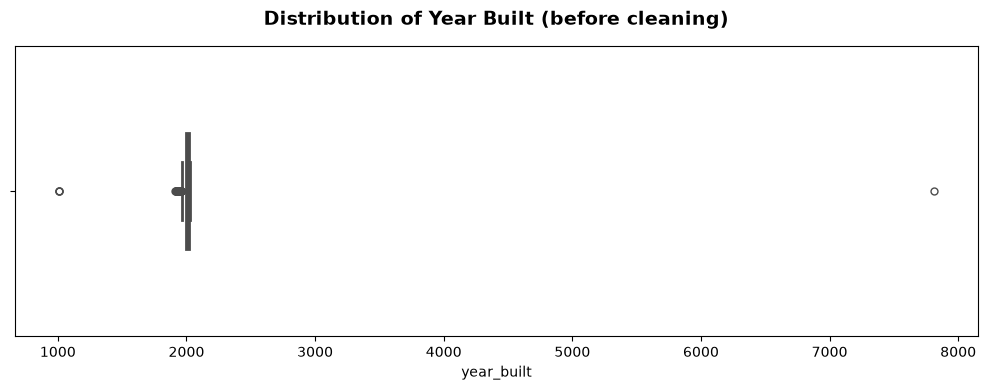

In [22]:
# Box plot 
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df[column], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Distribution of Year Built (before cleaning)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel(column)

plt.tight_layout()
plt.show()

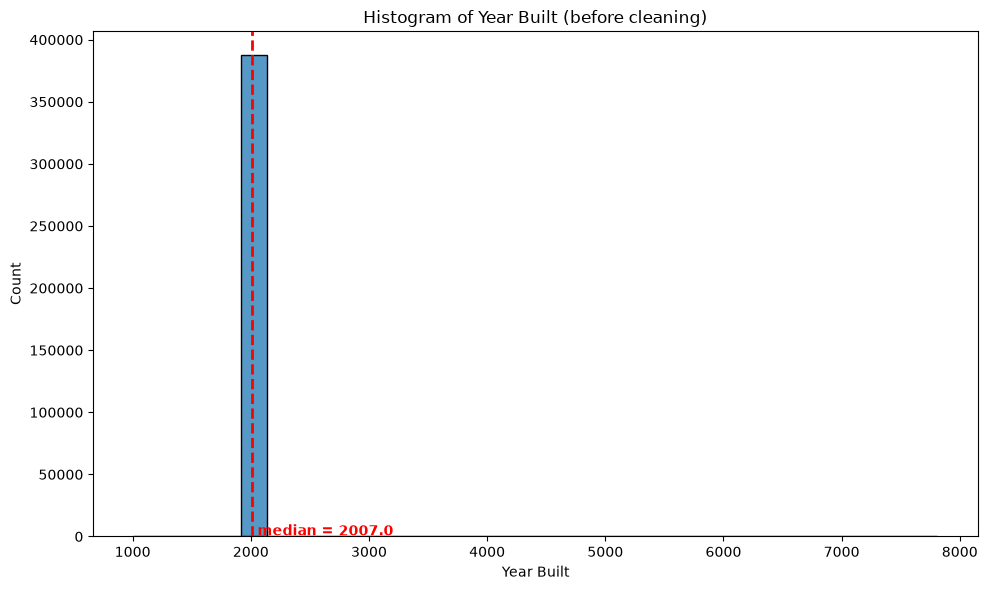

In [23]:
#Histogram
plt.figure(figsize=(10, 6))
sns.histplot(x=df[column], bins=30)

median_year = df[column].median()
plt.axvline(median_year, color='red', linestyle='--', linewidth=2)

plt.text(median_year + 50, 1000, f'median = {median_year}', color='red', fontweight='bold')

plt.title('Histogram of Year Built (before cleaning)')
plt.xlabel('Year Built')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

The **minimum** and **maximum** values of `year_built` are calculated on the data **before** the range-based cleaning below (that is, after removing duplicates and rows with a missing `year_built`).

In [24]:
print(f"Minimum built year: {df_copy['year_built'].min()}")
print(f"Maximum built year: {df_copy['year_built'].max()}")

Minimum built year: 1006.0
Maximum built year: 7811.0


### **Remove invalid values in `year_built`**

The IQR method flagged extreme values in `year_built`, but a statistical rule alone is not enough to decide which of them are errors. The `.describe()` summary showed a minimum of 1006 and a maximum of 7811, which are impossible values, while other flagged values may be real, old buildings that simply sit far from the median.

Instead of removing every value flagged by the IQR, a **logical range** based on domain knowledge is used:

- **Upper limit (2026, the latest year in the contract dates):** a building cannot have been built in the future, so any later year is a data entry error. Buildings from 2026 would be kept, since they may be newly completed.
- **Lower limit (1850):** residential buildings in Seoul built before this year are not plausible in a rental dataset. The limit is intentionally permissive so that genuinely old buildings are not discarded by mistake.

Only **4 rows** fell outside this range (three with year 1006 and one with year 7811), which is a negligible share of the dataset. After removing them, `year_built` ranges from 1910 to 2025, which is a realistic span for buildings in Seoul.

In [25]:
MIN_YEAR = 1850
MAX_YEAR = 2026

rows_before = len(df_copy)

# Rows that will be removed (for documentation)
invalid_years = df_copy[~df_copy['year_built'].between(MIN_YEAR, MAX_YEAR)]
print(f"Invalid year_built values found: {len(invalid_years):,}")
print(invalid_years['year_built'].value_counts().sort_index().head(20))

# Keep only rows inside the valid range
df_copy = df_copy[df_copy['year_built'].between(MIN_YEAR, MAX_YEAR)].reset_index(drop=True)

rows_dropped = rows_before - len(df_copy)
print(f"\nRows before: {rows_before:,} | Rows after: {len(df_copy):,}")
print(f"Rows dropped: {rows_dropped:,} ({rows_dropped / rows_before * 100:.4f}%)")
print(f"year_built range now: {df_copy['year_built'].min():.0f} - {df_copy['year_built'].max():.0f}")

Invalid year_built values found: 4
year_built
1006.0    3
7811.0    1
Name: count, dtype: int64

Rows before: 387,331 | Rows after: 387,327
Rows dropped: 4 (0.0010%)
year_built range now: 1910 - 2025


In [26]:
df_copy.shape

(387327, 24)

After cleaning, the boxplot and histogram of `year_built` are drawn again with `df_copy`.

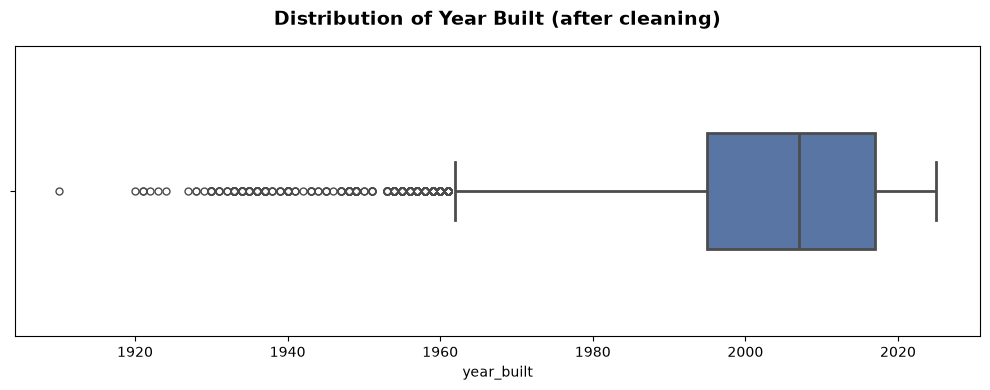

In [27]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_copy[column],
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Distribution of Year Built (after cleaning)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel(column)

plt.tight_layout()
plt.show()

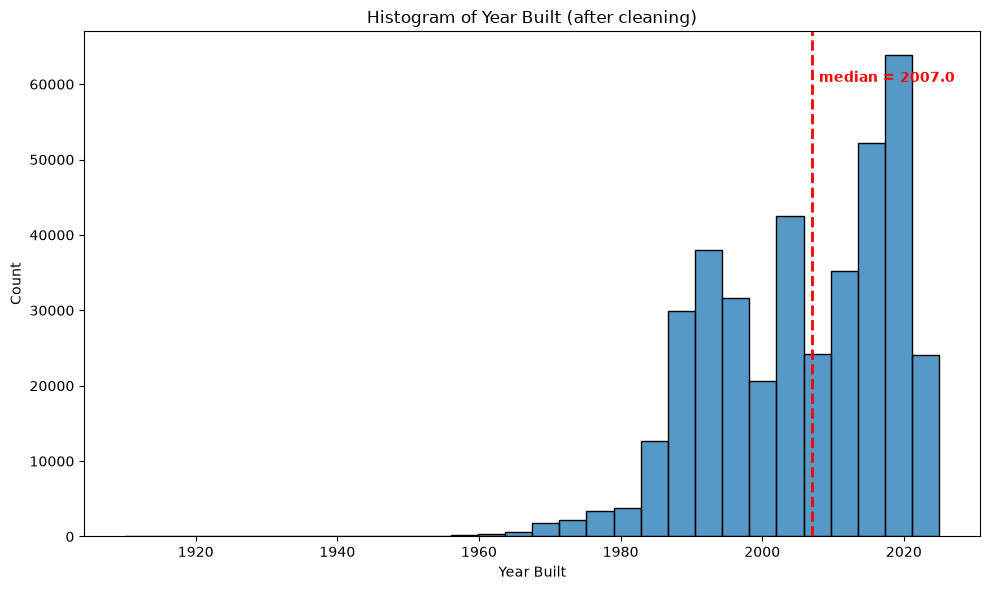

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_copy[column], bins=30)

median_year = df_copy[column].median()
plt.axvline(median_year, color='red', linestyle='--', linewidth=2)

plt.text(median_year + 1, plt.gca().get_ylim()[1] * 0.9, f'median = {median_year}', color='red', fontweight='bold')

plt.title('Histogram of Year Built (after cleaning)')
plt.xlabel('Year Built')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [29]:
decades = (df_copy['year_built'] // 10 * 10).astype(int)
decade_table = pd.DataFrame({'records': decades.value_counts().sort_index()})
decade_table['pct'] = (decade_table['records'] / len(df_copy) * 100).round(2)
display(decade_table)
print(f"Median year_built: {df_copy['year_built'].median():.0f}")

,records,pct
year_built,,
1910,1,0.00
1920,10,0.00
1930,83,0.02
1940,67,0.02
1950,235,0.06
1960,1386,0.36
1970,8342,2.15
1980,37786,9.76
1990,83100,21.45


Median year_built: 2007


**Interpretation — `year_built`.** After removing the impossible values, the median construction year is 2007 and `year_built` ranges from 1910 to 2025. Records are concentrated in buildings from the 1990s onward, with the 2010s as the largest decade (31.03% of records), followed by the 1990s (21.45%) and the 2000s (20.91%). The 2020s, which cover only 2020–2025, already account for 14.23%. Buildings from the 1970s or earlier are rare (2.15% for the 1970s and less than 0.4% for each earlier decade). These shares describe rental contracts, not the stock of buildings in Seoul, so they do not by themselves indicate a construction boom.

## **5: Univariate analysis**

Univariate analysis of the numeric variables:
- `deposit_10k_krw`: expected strong right skew.
- `monthly_rent_10k_krw`: equals 0 for every Jeonse contract, so it is analyzed on Wolse contracts only to avoid a false peak at 0.
- `leased_area_sqm`: check minimum and maximum ranges.
- `floor`: negative values are basements and are not treated as outliers.
- `year_built`: check whether there was a construction boom in any decade.

### **Distribution Analysis of `deposit_10k_krw`**

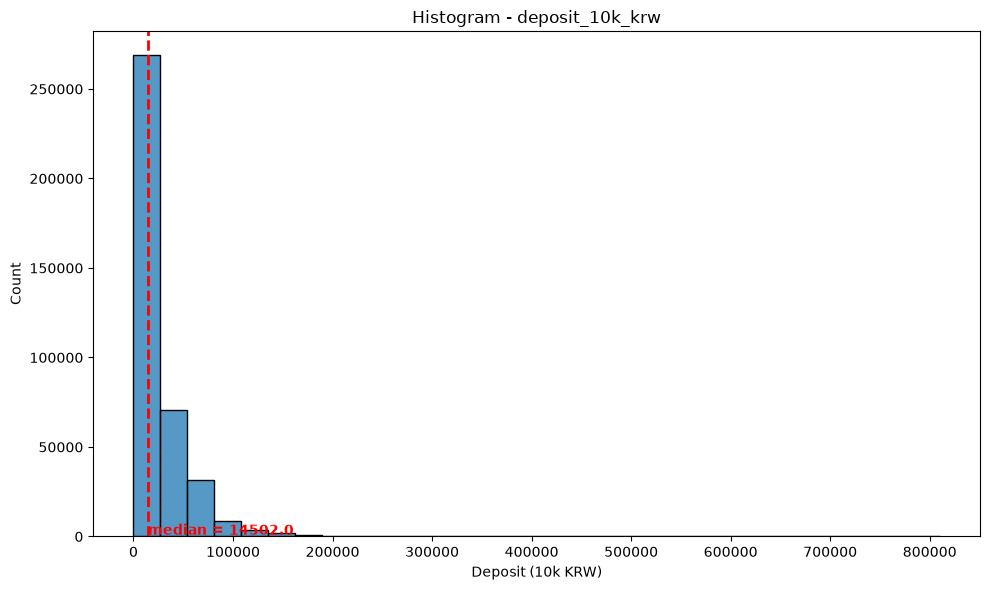

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_copy['deposit_10k_krw'], bins=30)

median_deposit = df_copy['deposit_10k_krw'].median()
plt.axvline(median_deposit, color='red', linestyle='--', linewidth=2)

plt.text(median_deposit + 1, 1000, f'median = {median_deposit}', color='red', fontweight='bold')

plt.title('Histogram - deposit_10k_krw')
plt.xlabel('Deposit (10k KRW)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

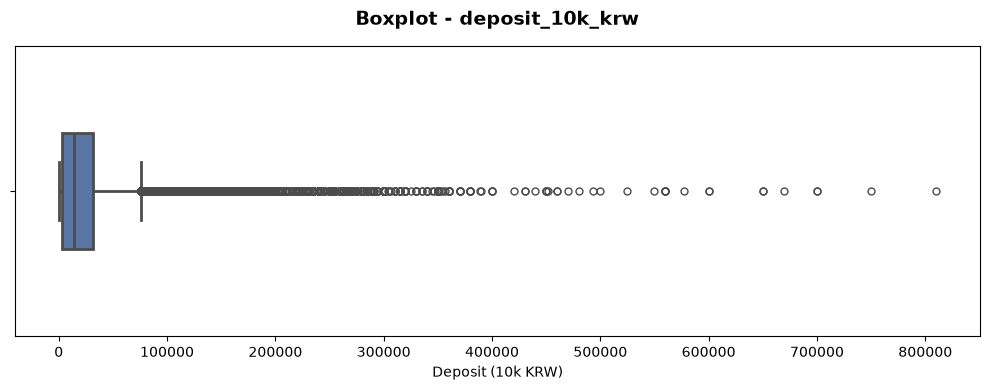

In [31]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_copy['deposit_10k_krw'], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Boxplot - deposit_10k_krw', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Deposit (10k KRW)')

plt.tight_layout()
plt.show()

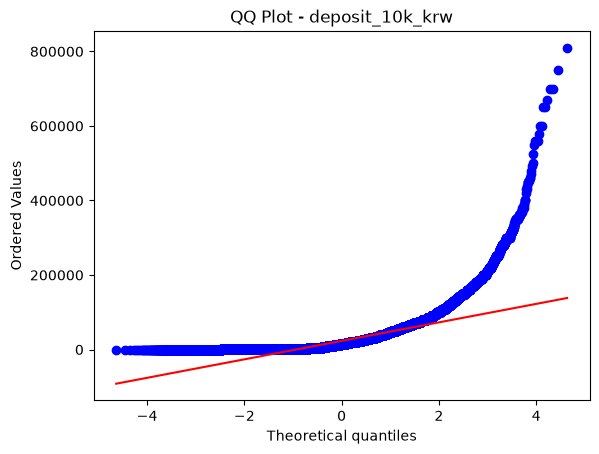

In [32]:
stats.probplot(df_copy['deposit_10k_krw'], dist="norm", plot=plt)
plt.title('QQ Plot - deposit_10k_krw')
plt.show()

In [33]:
df_copy['deposit_10k_krw'].mean(), df_copy['deposit_10k_krw'].median()

(np.float64(23336.268460499785), np.float64(14502.0))

In [34]:
df_copy['deposit_10k_krw'].skew()

np.float64(3.028110750712967)

In [35]:
Q1 = df_copy['deposit_10k_krw'].quantile(0.25)
Q3 = df_copy['deposit_10k_krw'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy['deposit_10k_krw'] < lower_bound) | (df_copy['deposit_10k_krw'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print(f"Share of rows flagged: {len(outliers) / len(df_copy) * 100:.2f}%")
print("Maximum deposit:", df_copy['deposit_10k_krw'].max())

Lower bound: -40500.0
Upper bound: 75500.0
Number of outliers: 19798
Share of rows flagged: 5.11%
Maximum deposit: 810000


### **Interpretation — `deposit_10k_krw`**

The distribution of `deposit_10k_krw` is strongly right-skewed (skew = 3.03), confirmed by the gap between the mean (23,336) and the median (14,502). This pattern is typical of price variables: a small group of very high deposits (up to 810,000, i.e. 8.1 billion KRW) pulls the mean upward without representing the typical contract.

The IQR method flags 19,798 rows (5.11% of the dataset) as outliers, above an upper bound of 75,500. Unlike the invalid values found in `year_built`, these are not data entry errors: they correspond to real, high-value contracts, and the district and building-type comparisons below show where they concentrate. Removing them would artificially bias the analysis downward, so they are **kept**.

The QQ plot shows points following the theoretical normal line reasonably well in the center, but curving sharply upward at the right tail, a visual signature consistent with a lognormal-like distribution. This suggests that a **log transformation** (`np.log1p`) should be considered before using this variable in linear regression, since linear models perform better with more symmetric distributions. This decision is deferred to the feature engineering phase.

### **Distribution Analysis of `monthly_rent_10k_krw`**

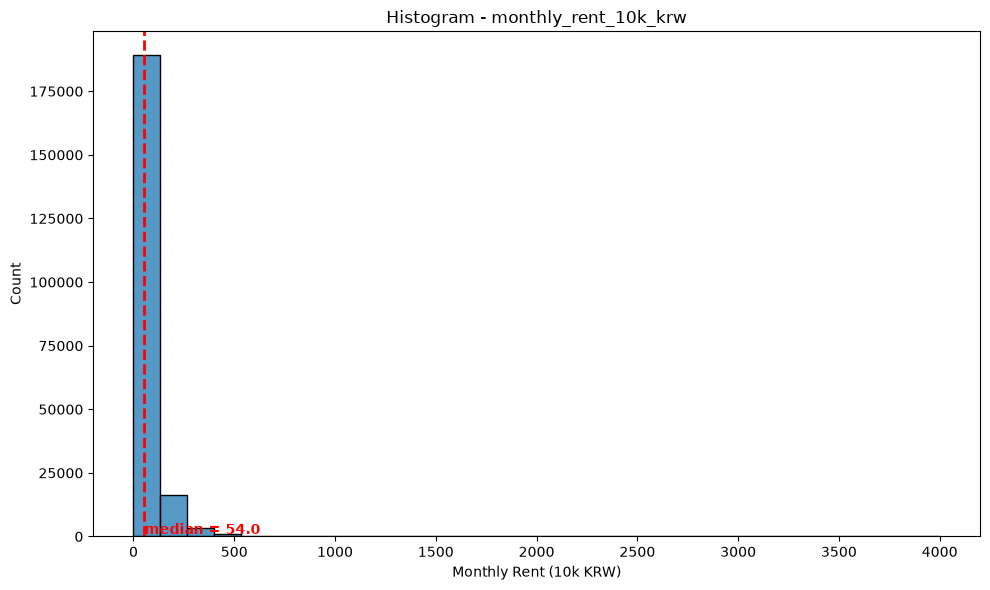

In [36]:
df_wolse = df_copy[df_copy['lease_type'] == 'Monthly rent']

plt.figure(figsize=(10, 6))
sns.histplot(x=df_wolse['monthly_rent_10k_krw'], bins=30)

median_monthly_rent = df_wolse['monthly_rent_10k_krw'].median()
plt.axvline(median_monthly_rent, color='red', linestyle='--', linewidth=2)

plt.text(median_monthly_rent + 1, 1000, f'median = {median_monthly_rent}', color='red', fontweight='bold')

plt.title('Histogram - monthly_rent_10k_krw')
plt.xlabel('Monthly Rent (10k KRW)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

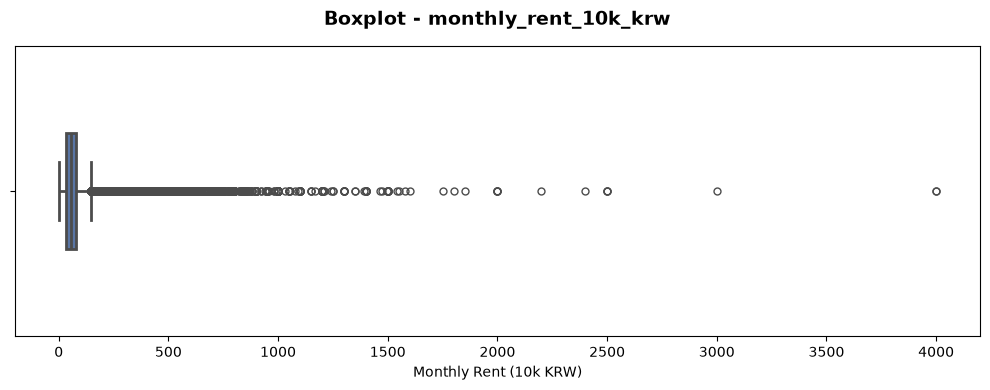

In [37]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_wolse['monthly_rent_10k_krw'], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Boxplot - monthly_rent_10k_krw', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Monthly Rent (10k KRW)')

plt.tight_layout()
plt.show()

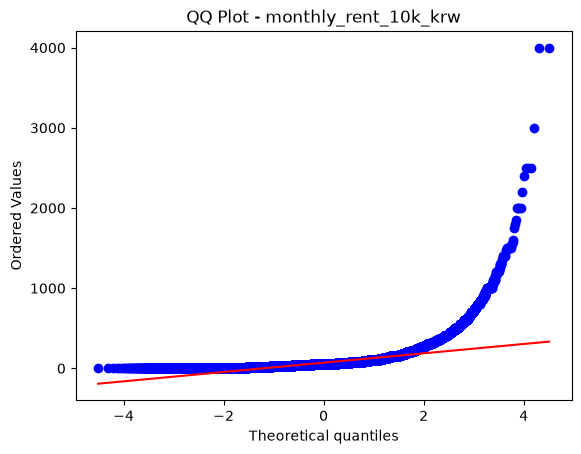

In [38]:
stats.probplot(df_wolse['monthly_rent_10k_krw'], dist="norm", plot=plt)
plt.title('QQ Plot - monthly_rent_10k_krw')
plt.show()

In [39]:
df_wolse['monthly_rent_10k_krw'].mean(), df_wolse['monthly_rent_10k_krw'].median()

(np.float64(70.79053684995463), np.float64(54.0))

In [40]:
df_wolse['monthly_rent_10k_krw'].skew()

np.float64(7.283701771680256)

In [41]:
print(f"Wolse contracts: n = {len(df_wolse):,} ({len(df_wolse) / len(df_copy) * 100:.2f}% of the dataset)")
print(f"Skew, Wolse only: {df_wolse['monthly_rent_10k_krw'].skew():.3f}")
print(f"Skew, all contracts with the zeros of Jeonse (n = {len(df_copy):,}): {df_copy['monthly_rent_10k_krw'].skew():.3f}")

Wolse contracts: n = 210,543 (54.36% of the dataset)
Skew, Wolse only: 7.284
Skew, all contracts with the zeros of Jeonse (n = 387,327): 7.010


In [42]:
Q1 = df_wolse['monthly_rent_10k_krw'].quantile(0.25)
Q3 = df_wolse['monthly_rent_10k_krw'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_wolse[(df_wolse['monthly_rent_10k_krw'] < lower_bound) | (df_wolse['monthly_rent_10k_krw'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print(f"Share of Wolse rows flagged: {len(outliers) / len(df_wolse) * 100:.2f}%")
print("Maximum monthly rent:", df_wolse['monthly_rent_10k_krw'].max())

Lower bound: -32.5
Upper bound: 147.5
Number of outliers: 18567
Share of Wolse rows flagged: 8.82%
Maximum monthly rent: 4000


### **Interpretation — `monthly_rent_10k_krw` (Wolse only)**

After filtering to Monthly rent (Wolse) contracts only (n = 210,543, 54.36% of the dataset), the distribution shows a mean of 70.79, a median of 54 and a skew of 7.28. The skew is still very high and slightly higher than the skew obtained when the zero rents of Jeonse contracts are included (7.01), so the filter does not remove the skew: it comes from the right tail of real monthly rents. The gap between the mean (70.79) and the median (54) confirms that a small group of very high-rent properties pulls the mean upward.

The IQR method flags 18,567 Wolse rows (8.82% of Wolse contracts) as outliers, above an upper bound of 147.5, with a maximum of 4,000 (40 million KRW per month). As with the deposit variable, these likely reflect real high-end rental contracts rather than data errors, so they are kept. A **log transformation** will also be considered for this variable at the modeling stage, given the persistent right skew typical of rent data.

### **Distribution Analysis of `leased_area_sqm`**

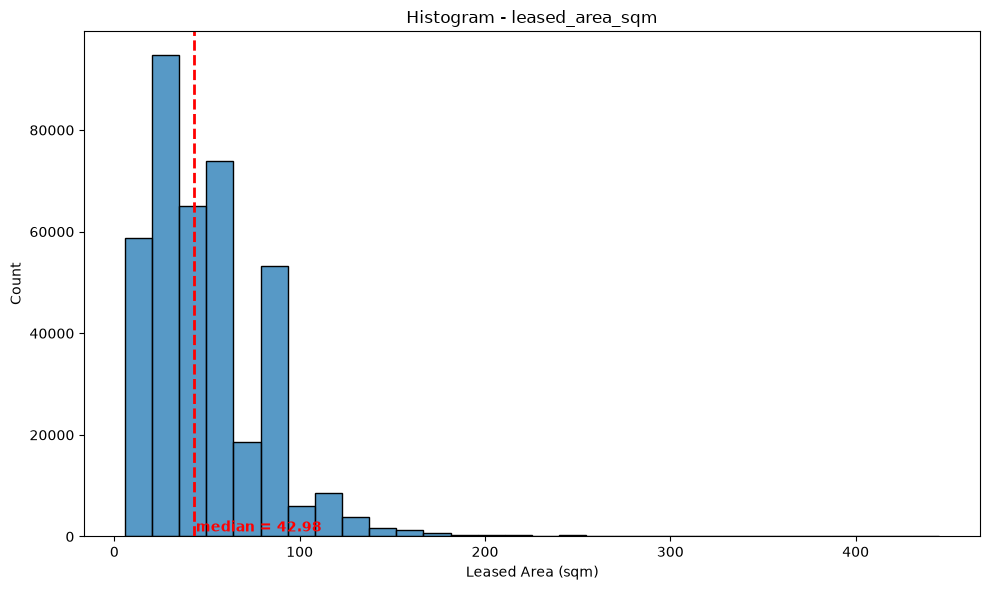

In [43]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_copy['leased_area_sqm'], bins=30)

median_leased_area = df_copy['leased_area_sqm'].median()
plt.axvline(median_leased_area, color='red', linestyle='--', linewidth=2)

plt.text(median_leased_area + 1, 1000, f'median = {median_leased_area}', color='red', fontweight='bold')

plt.title('Histogram - leased_area_sqm')
plt.xlabel('Leased Area (sqm)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

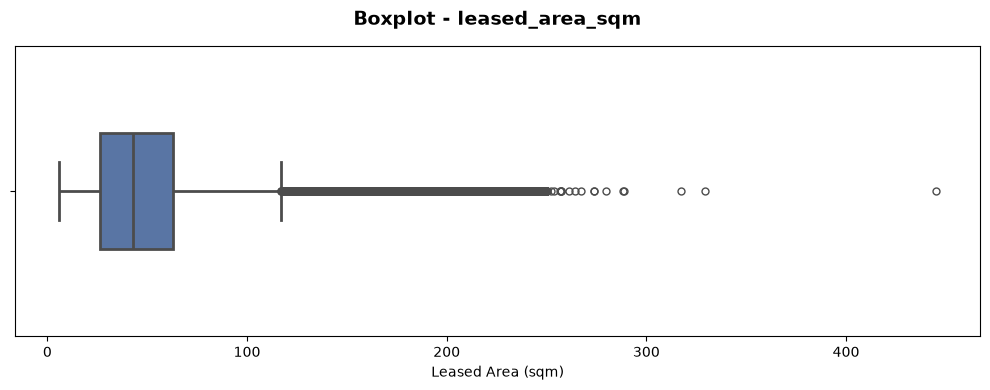

In [44]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_copy['leased_area_sqm'], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Boxplot - leased_area_sqm', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Leased Area (sqm)')

plt.tight_layout()
plt.show()

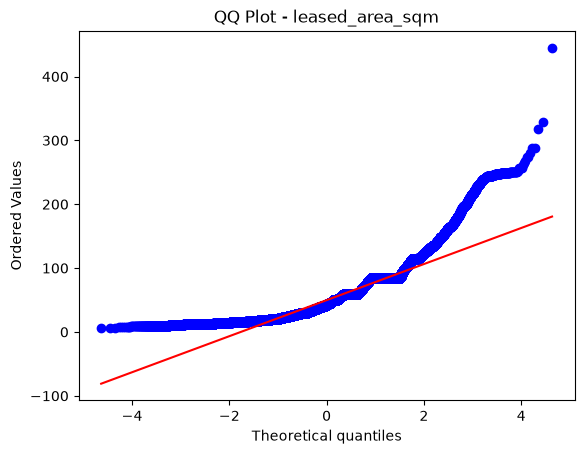

In [45]:
stats.probplot(df_copy['leased_area_sqm'], dist="norm", plot=plt)
plt.title('QQ Plot - leased_area_sqm')
plt.show()

In [46]:
df_copy['leased_area_sqm'].mean(), df_copy['leased_area_sqm'].median()

(np.float64(49.83565333684458), np.float64(42.98))

In [47]:
df_copy['leased_area_sqm'].skew()

np.float64(1.415763080063269)

In [48]:
Q1 = df_copy['leased_area_sqm'].quantile(0.25)
Q3 = df_copy['leased_area_sqm'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy['leased_area_sqm'] < lower_bound) | (df_copy['leased_area_sqm'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print(f"Share of rows flagged: {len(outliers) / len(df_copy) * 100:.2f}%")
print("Maximum area:", df_copy['leased_area_sqm'].max())

Lower bound: -27.907499999999995
Upper bound: 117.23249999999999
Number of outliers: 10449
Share of rows flagged: 2.70%
Maximum area: 445.12


In [49]:
print("Most frequent leased areas (rounded to the nearest sqm):")
print(df_copy['leased_area_sqm'].round(0).value_counts().head(8))

Most frequent leased areas (rounded to the nearest sqm):
leased_area_sqm
85.0    40043
60.0    33725
30.0    16900
20.0    11709
18.0    11418
50.0    10423
40.0    10116
29.0     7821
Name: count, dtype: int64


### **Interpretation — `leased_area_sqm`**

This variable shows a more moderate right skew (1.42) than the monetary variables (mean 49.84 sqm, median 42.98 sqm), which is expected given that living space has a more natural physical ceiling than price.

The histogram shows several distinct peaks rather than a smooth curve. The most frequent areas, rounded to the nearest sqm, are 85 (40,043 records) and 60 (33,725), followed by 30 (16,900) and 20 (11,709). This is consistent with **standardized unit sizes** common in South Korean construction (for example units marketed as 59㎡ or 84㎡), rather than random noise.

The IQR method flags 10,449 outliers (2.70% of the rows), above an upper bound of 117.23 sqm, with a maximum value of 445.12 sqm. Such areas are plausible for large houses or penthouses, but the extreme upper values are spot-checked in the validation checks below. No rows are removed.

### **Validation checks (diagnostic only)**

The upper tail of `leased_area_sqm` and a few implausible price/area combinations are inspected. Hypothesis: in multi-household houses the reported area may be the area of the whole building rather than of the rented unit. These checks only report; **no rows are removed**.

In [50]:
large_area = df_copy[df_copy['leased_area_sqm'] > 250]
print(f"Rows with leased_area_sqm > 250: {len(large_area):,}")
display(large_area[['district_name', 'building_type', 'lease_type', 'leased_area_sqm',
                    'deposit_10k_krw', 'monthly_rent_10k_krw']]
        .sort_values('leased_area_sqm', ascending=False).head(20))
display(large_area['building_type'].value_counts())

Rows with leased_area_sqm > 250: 18


,district_name,building_type,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw
385854,Gwanak-gu,Officetel,Monthly rent,445.120,1000,55
279402,Geumcheon-gu,Row house / Villa (multi-unit),Monthly rent,329.250,1000,50
95536,Yongsan-gu,Apartment,Monthly rent,317.360,110000,120
150936,Seocho-gu,Row house / Villa (multi-unit),Monthly rent,288.570,35000,130
100363,Seocho-gu,Row house / Villa (multi-unit),Monthly rent,288.400,30000,1000
275124,Seodaemun-gu,Row house / Villa (multi-unit),Monthly rent,280.010,1000,35
26057,Gangnam-gu,Apartment,Monthly rent,273.960,40000,4000
348621,Seongdong-gu,Apartment,Monthly rent,273.928,810000,1000
3143,Seocho-gu,Apartment,Monthly rent,267.100,20000,1400
234935,Mapo-gu,Row house / Villa (multi-unit),Jeonse (deposit only),264.220,130000,0


building_type
Apartment                         10
Row house / Villa (multi-unit)     7
Officetel                          1
Name: count, dtype: int64

In [51]:
suspect = df_copy[(df_copy['leased_area_sqm'] > 130) & (df_copy['deposit_10k_krw'] < 1000)]
print(f"Rows with leased_area_sqm > 130 and deposit_10k_krw < 1000: {len(suspect):,}")

suspect_types = pd.DataFrame({
    'suspect_rows': suspect['building_type'].value_counts(),
    'suspect_pct': (suspect['building_type'].value_counts(normalize=True) * 100).round(2),
    'all_rows_pct': (df_copy['building_type'].value_counts(normalize=True) * 100).round(2),
})
display(suspect_types)

display(df_copy.groupby('building_type')['leased_area_sqm'].describe().round(2))

Rows with leased_area_sqm > 130 and deposit_10k_krw < 1000: 435


,suspect_rows,suspect_pct,all_rows_pct
building_type,,,
Apartment,38.0,8.74,41.81
Detached / Multi-household house,378.0,86.90,23.09
Officetel,NaN,NaN,12.78
Row house / Villa (multi-unit),19.0,4.37,22.32


,count,mean,std,min,25%,50%,75%,max
building_type,,,,,,,,
Apartment,161959.0,69.04,28.82,10.32,50.14,59.99,84.92,317.36
Detached / Multi-household house,89434.0,37.37,26.43,10.00,20.00,31.53,45.00,249.93
Officetel,49487.0,27.38,13.75,5.69,19.13,24.02,29.69,445.12
Row house / Villa (multi-unit),86447.0,39.61,19.76,7.38,26.98,35.41,50.02,329.25


In [52]:
jeonse_zero_deposit = ((df_copy['lease_type'] == 'Jeonse (deposit only)') & (df_copy['deposit_10k_krw'] == 0)).sum()
wolse_zero_rent = ((df_copy['lease_type'] == 'Monthly rent') & (df_copy['monthly_rent_10k_krw'] == 0)).sum()
print(f"Jeonse rows with deposit == 0: {jeonse_zero_deposit:,}")
print(f"Wolse rows with monthly rent == 0: {wolse_zero_rent:,}")

Jeonse rows with deposit == 0: 0
Wolse rows with monthly rent == 0: 12


**Finding.** Only 18 rows exceed 250 sqm (10 Apartments, 7 Row houses / Villas and 1 Officetel), and no Detached / Multi-household house is among them (their maximum area is 249.93 sqm). Most of these rows have deposits in the tens or hundreds of thousands (10k KRW) and look like genuine large units, but three rows (an Officetel in Gwanak-gu and two Row houses / Villas in Geumcheon-gu and Seodaemun-gu) have a deposit of only 1,000 and a monthly rent of 35–55 for 280–445 sqm, which is hard to reconcile with those areas.

The hypothesis about multi-household houses is supported by the second check: 435 rows have an area above 130 sqm and a deposit below 1,000, and 86.90% of them are Detached / Multi-household houses, against 23.09% of all rows (Apartments 8.74%, Row houses / Villas 4.37%, Officetels none). Large areas combined with very low deposits are therefore concentrated in this building type, which is consistent with the reported area being that of the whole building rather than of the rented unit, although the dataset cannot confirm it.

There are no Jeonse rows with a deposit of 0, and 12 Wolse rows with a monthly rent of 0, which contradicts their Wolse label. **No rows were removed**: these values cannot be verified against the source and the affected rows are few. The area of Detached / Multi-household houses should be interpreted with caution in the modeling phase.

### **Distribution Analysis of `floor`**

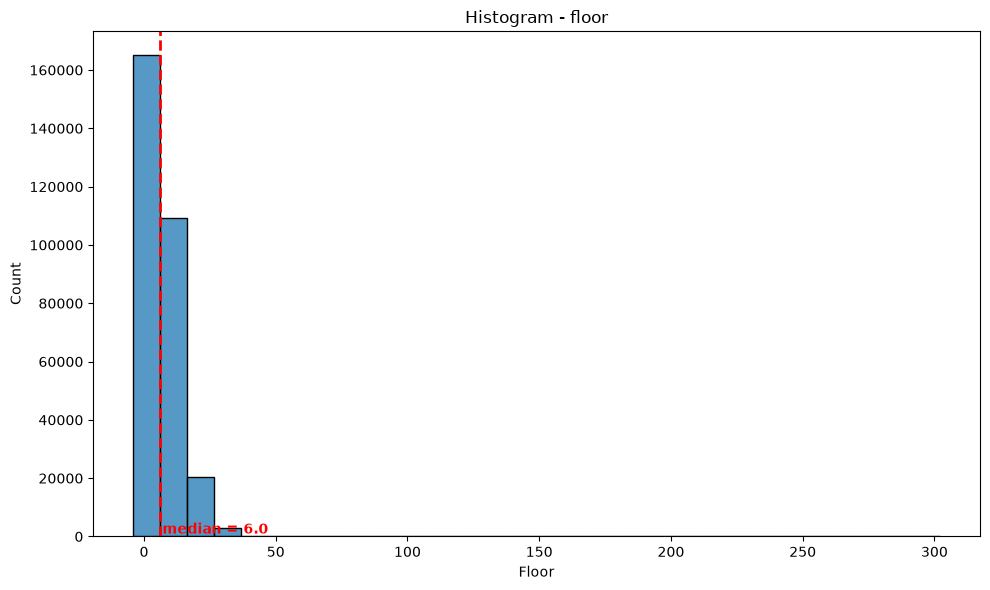

In [53]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_copy['floor'], bins=30)

median_floor = df_copy['floor'].median()
plt.axvline(median_floor, color='red', linestyle='--', linewidth=2)

plt.text(median_floor + 1, 1000, f'median = {median_floor}', color='red', fontweight='bold')

plt.title('Histogram - floor')
plt.xlabel('Floor')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

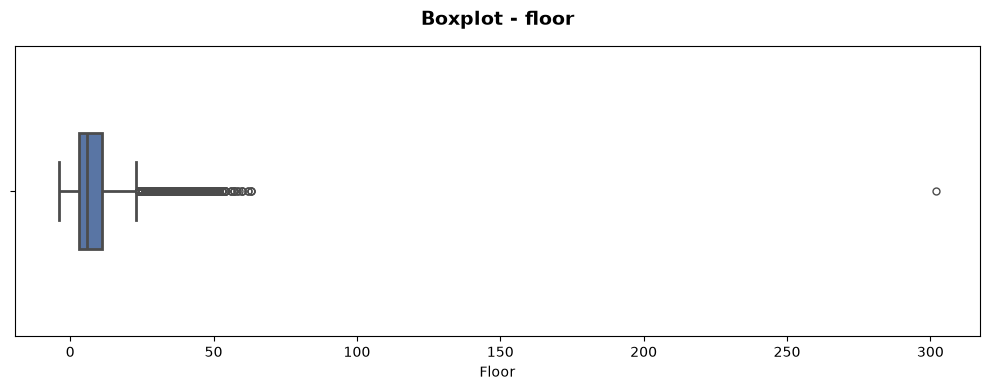

In [54]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_copy['floor'], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Boxplot - floor', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Floor')

plt.tight_layout()
plt.show()

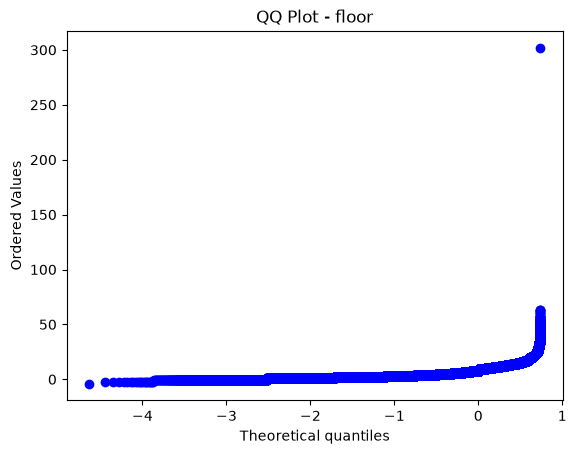

In [55]:
stats.probplot(df_copy['floor'], dist="norm", plot=plt)
plt.title('QQ Plot - floor')
plt.show()

In [56]:
df_copy['floor'].mean(), df_copy['floor'].median()

(np.float64(7.519115924174116), np.float64(6.0))

In [57]:
df_copy['floor'].skew()

np.float64(1.918493863647546)

In [58]:
Q1 = df_copy['floor'].quantile(0.25)
Q3 = df_copy['floor'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy['floor'] < lower_bound) | (df_copy['floor'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Lower bound: -9.0
Upper bound: 23.0
Number of outliers: 5981


### **Interpretation — `floor`**

The `floor` variable showed a moderate right skew (1.92), with most contracts concentrated in low-to-mid floors (median = 6, mean = 7.52). The IQR upper bound (23.0) flagged 5,981 rows, but most of them are plausible floors of tall residential buildings.

However, the maximum value was 302 (a single row, a Row house / Villa in Gwangjin-gu built in 2018), which is not a plausible floor number for a residential building: even Seoul's tallest mixed-use building (Lotte World Tower) has around 123 floors. This indicated a **data entry error**, not a legitimate extreme value.

Rather than applying the IQR-based upper bound, which would have incorrectly discarded genuinely tall but valid residential buildings, a domain-based logical range is used (similar to the approach used for `year_built`), and the row outside that range is removed right below.

### **Remove invalid values in `floor`**

The maximum value of `floor` was 302, which is not plausible for a residential building. As done with `year_built`, a logical range based on domain knowledge is used instead of the IQR bound. Missing values (`NaN`) are kept, since they mostly correspond to detached houses that have no floor number.

In [59]:
df_copy.loc[df_copy['floor'] > 70, ['district_name', 'building_type', 'floor', 'year_built']].sort_values('floor', ascending=False)

,district_name,building_type,floor,year_built
146987,Gwangjin-gu,Row house / Villa (multi-unit),302.0,2018.0


In [60]:
MAX_FLOOR = 100
rows_before = len(df_copy)

df_copy = df_copy[df_copy['floor'].isna() | (df_copy['floor'] <= MAX_FLOOR)].reset_index(drop=True)

print(f"Rows dropped: {rows_before - len(df_copy):,}")
print(f"floor max now: {df_copy['floor'].max()}")

Rows dropped: 1
floor max now: 63.0


### **Sample selection check**

The cleaned `df_copy` is compared with `df` to check that the cleaning does not change the composition of the sample. The table of each variable shows the rows and share in `df`, the rows and share kept in `df_copy`, and the percentage of the rows of each category that was retained.

In [61]:
df_cmp = df.assign(contract_type=df['contract_type'].fillna('Not specified'))


def retention_table(column):
    before = df_cmp[column].value_counts()
    after = df_copy[column].value_counts().reindex(before.index).fillna(0).astype(int)
    table = pd.DataFrame({
        'df_rows': before,
        'df_pct': (before / len(df_cmp) * 100).round(2),
        'df_copy_rows': after,
        'df_copy_pct': (after / len(df_copy) * 100).round(2),
    })
    table['retained_pct'] = (table['df_copy_rows'] / table['df_rows'] * 100).round(2)
    return table.rename_axis(column)


print(f"Rows: df = {len(df):,} | df_copy = {len(df_copy):,} | retained = {len(df_copy) / len(df) * 100:.2f}%")
print(f"Rows dropped in total: {len(df) - len(df_copy):,} ({(1 - len(df_copy) / len(df)) * 100:.2f}%) | rows with missing year_built in df: {df['year_built'].isna().sum():,}")
for col in ['building_type', 'lease_type', 'contract_type', 'registration_year']:
    display(retention_table(col))

# Reference values from the previous version of the cleaning, where contract_period,
# contract_start and contract_end were required to be non-missing
OLD_ROWS_KEPT = 331_869
OLD_DETACHED_KEPT = 74_108
detached = 'Detached / Multi-household house'
detached_before = (df['building_type'] == detached).sum()
detached_now = (df_copy['building_type'] == detached).sum()
print(f"\nPrevious cleaning: {OLD_ROWS_KEPT:,} rows kept ({OLD_ROWS_KEPT / len(df) * 100:.2f}%) | current cleaning: {len(df_copy):,} ({len(df_copy) / len(df) * 100:.2f}%)")
print(f"Detached / Multi-household: {detached_before:,} in df | previous cleaning {OLD_DETACHED_KEPT:,} ({OLD_DETACHED_KEPT / detached_before - 1:+.1%}) | current cleaning {detached_now:,} ({detached_now / detached_before - 1:+.1%})")

Rows: df = 400,000 | df_copy = 387,326 | retained = 96.83%
Rows dropped in total: 12,674 (3.17%) | rows with missing year_built in df: 12,650


,df_rows,df_pct,df_copy_rows,df_copy_pct,retained_pct
building_type,,,,,
Apartment,162006,40.50,161959,41.81,99.97
Detached / Multi-household house,100130,25.03,89434,23.09,89.32
Row house / Villa (multi-unit),86481,21.62,86446,22.32,99.96
Officetel,51383,12.85,49487,12.78,96.31


,df_rows,df_pct,df_copy_rows,df_copy_pct,retained_pct
lease_type,,,,,
Monthly rent,219690,54.92,210543,54.36,95.84
Jeonse (deposit only),180310,45.08,176783,45.64,98.04


,df_rows,df_pct,df_copy_rows,df_copy_pct,retained_pct
contract_type,,,,,
New,254455,63.61,245736,63.44,96.57
Renewal,94165,23.54,92618,23.91,98.36
Not specified,51380,12.84,48972,12.64,95.31


,df_rows,df_pct,df_copy_rows,df_copy_pct,retained_pct
registration_year,,,,,
2023,100028,25.01,98261,25.37,98.23
2024,100000,25.00,92664,23.92,92.66
2025,100000,25.00,98049,25.31,98.05
2022,99963,24.99,98343,25.39,98.38
2021,9,0.00,9,0.00,100.00



Previous cleaning: 331,869 rows kept (82.97%) | current cleaning: 387,326 (96.83%)
Detached / Multi-household: 100,130 in df | previous cleaning 74,108 (-26.0%) | current cleaning 89,434 (-10.7%)


**Finding.** The cleaning keeps 387,326 of 400,000 rows (96.83%), compared with 331,869 rows (82.97%) in the previous version, which required `contract_period`. The composition of the sample stays close to the original one: Apartments 40.50% → 41.81%, Detached / Multi-household houses 25.03% → 23.09%, Row houses / Villas 21.62% → 22.32% and Officetels 12.85% → 12.78%; Monthly rent 54.92% → 54.36% and Jeonse 45.08% → 45.64%; New contracts 63.61% → 63.44%, Renewals 23.54% → 23.91% and Not specified 12.84% → 12.64%.

Detached / Multi-household houses remain the most affected category: 89,434 of 100,130 rows are retained (89.32%, a drop of 10.7%), against 74,108 rows (a drop of 26.0%) in the previous version. Retention is also lower for Officetels (96.31%) than for Apartments (99.97%) and Row houses / Villas (99.96%), for Monthly rent (95.84%) than for Jeonse (98.04%), and for 2024 (92.66%) than for the other years (98.05% to 98.38%). Almost all of the remaining loss (12,674 rows in total) comes from the missing `year_built` (12,650 rows in `df`), which is required in this analysis. This residual selection effect is listed in the Limitations.

### **Recreate lease-type subsets**

After cleaning `floor`, the Wolse subset is rebuilt so that it matches the current `df_copy`, and a Jeonse subset is created for the following analysis.

In [62]:
df_wolse = df_copy[df_copy['lease_type'] == 'Monthly rent']
df_jeonse = df_copy[df_copy['lease_type'] == 'Jeonse (deposit only)']

print(f"Wolse: {len(df_wolse):,} rows | Jeonse: {len(df_jeonse):,} rows")

Wolse: 210,543 rows | Jeonse: 176,783 rows


Univariate analysis of the categorical variables:
- `district_name`: whether the 25 districts are balanced or a few dominate the sample.
- `building_type`: share of apartments, officetels, row houses/villas and detached houses.
- `lease_type`: share of Jeonse vs. Wolse; its balance matters because it is a possible classification target.
- `contract_type`: new vs. renewal and share of unspecified values.
- `renewal_right_used`: frequency of yes / no / not reported.

In [63]:
def analyze_categorical(df, column):
    """
    Univariate analysis for a categorical column:
    frequency table (absolute + percentage) and bar plot.
    """
    freq_table = df[column].value_counts(dropna=False)
    pct_table = df[column].value_counts(normalize=True, dropna=False) * 100

    summary = pd.DataFrame({
        'count': freq_table,
        'percentage': pct_table.round(2)
    })

    print(f"--- {column} ---")
    print(summary)

    plt.figure(figsize=(10, 6))
    order = freq_table.index
    sns.barplot(x=freq_table.values, y=order, orient='h')
    plt.title(f'Frequency - {column}')
    plt.xlabel('Count')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

    return summary

--- district_name ---
                 count  percentage
district_name                     
Songpa-gu        32327        8.35
Gangseo-gu       26820        6.92
Gangnam-gu       24998        6.45
Gwanak-gu        21664        5.59
Gangdong-gu      20888        5.39
Mapo-gu          19995        5.16
Yeongdeungpo-gu  19006        4.91
Seocho-gu        18727        4.83
Gwangjin-gu      16970        4.38
Dongjak-gu       16615        4.29
Eunpyeong-gu     15886        4.10
Nowon-gu         15722        4.06
Dongdaemun-gu    14265        3.68
Yangcheon-gu     14075        3.63
Guro-gu          13797        3.56
Jungnang-gu      13245        3.42
Seongbuk-gu      13037        3.37
Seongdong-gu     12251        3.16
Seodaemun-gu     11849        3.06
Yongsan-gu        9912        2.56
Geumcheon-gu      9364        2.42
Dobong-gu         8088        2.09
Gangbuk-gu        7205        1.86
Jung-gu           5564        1.44
Jongno-gu         5056        1.31


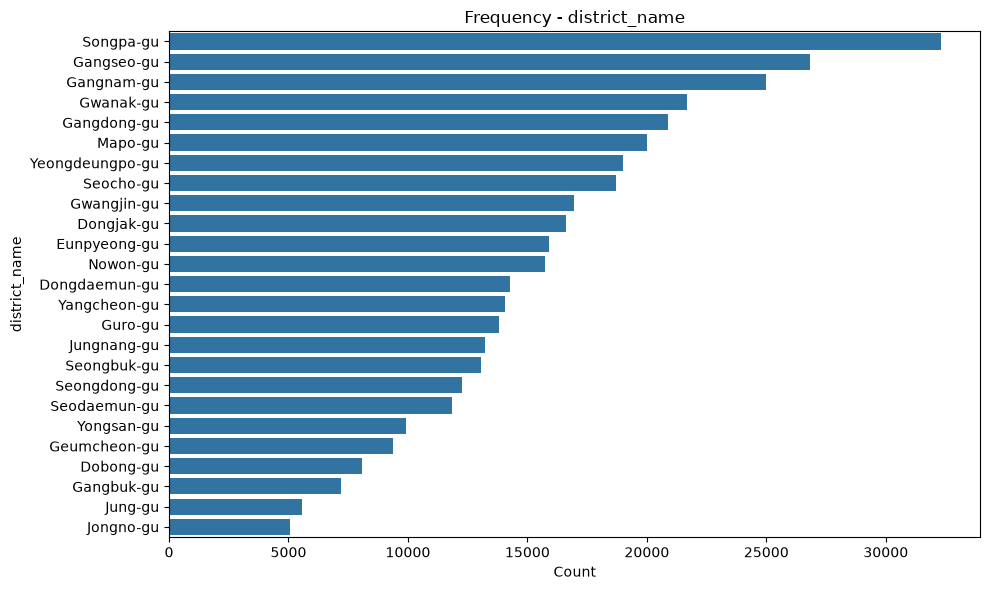

In [64]:
district_summary = analyze_categorical(df_copy, 'district_name')

--- building_type ---
                                   count  percentage
building_type                                       
Apartment                         161959       41.81
Detached / Multi-household house   89434       23.09
Row house / Villa (multi-unit)     86446       22.32
Officetel                          49487       12.78


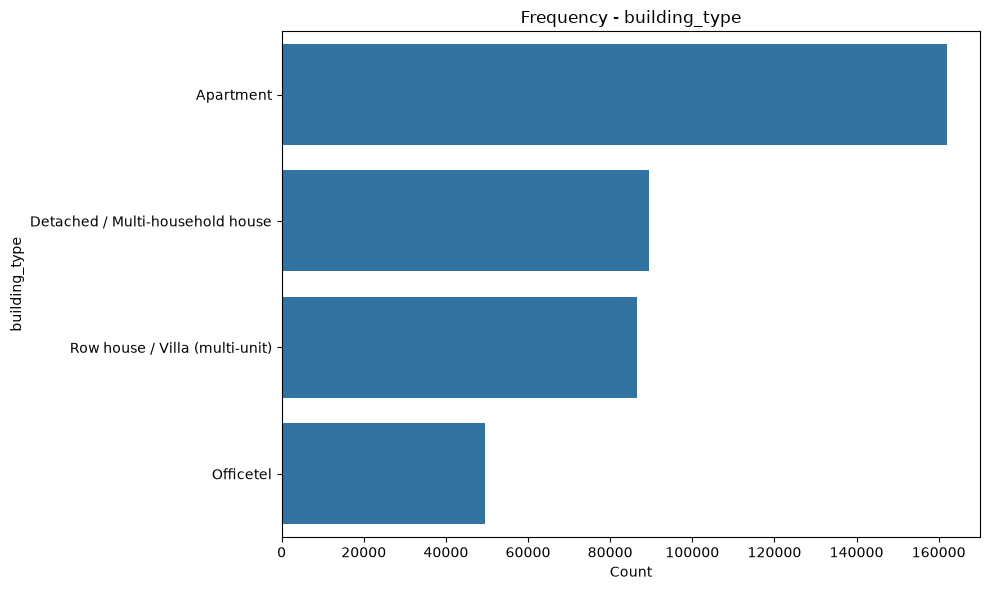

In [65]:
building_type_summary = analyze_categorical(df_copy, 'building_type')

--- lease_type ---
                        count  percentage
lease_type                               
Monthly rent           210543       54.36
Jeonse (deposit only)  176783       45.64


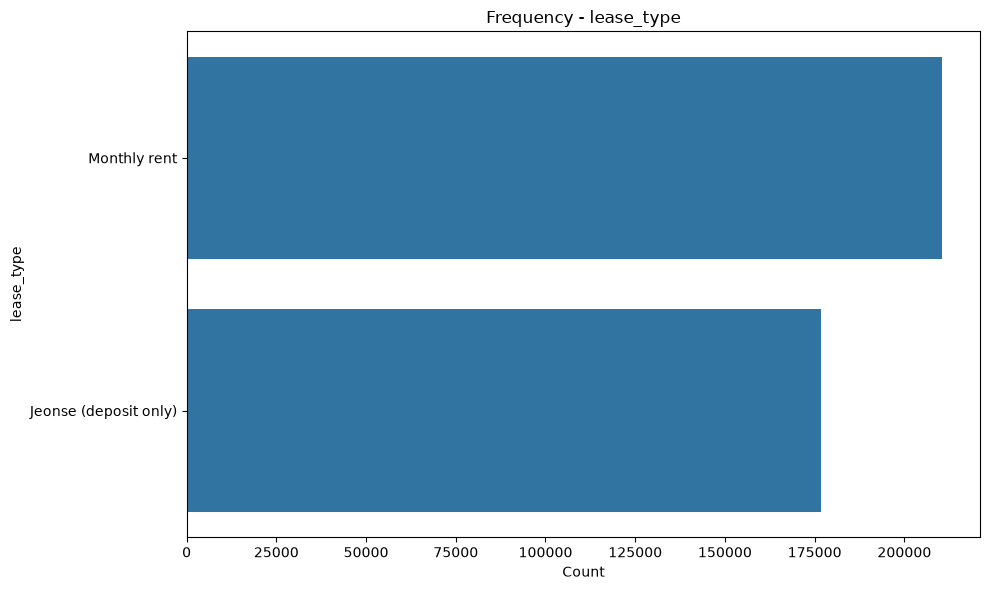

In [66]:
lease_type_summary = analyze_categorical(df_copy, 'lease_type')

--- contract_type ---
                count  percentage
contract_type                    
New            245736       63.44
Renewal         92618       23.91
Not specified   48972       12.64


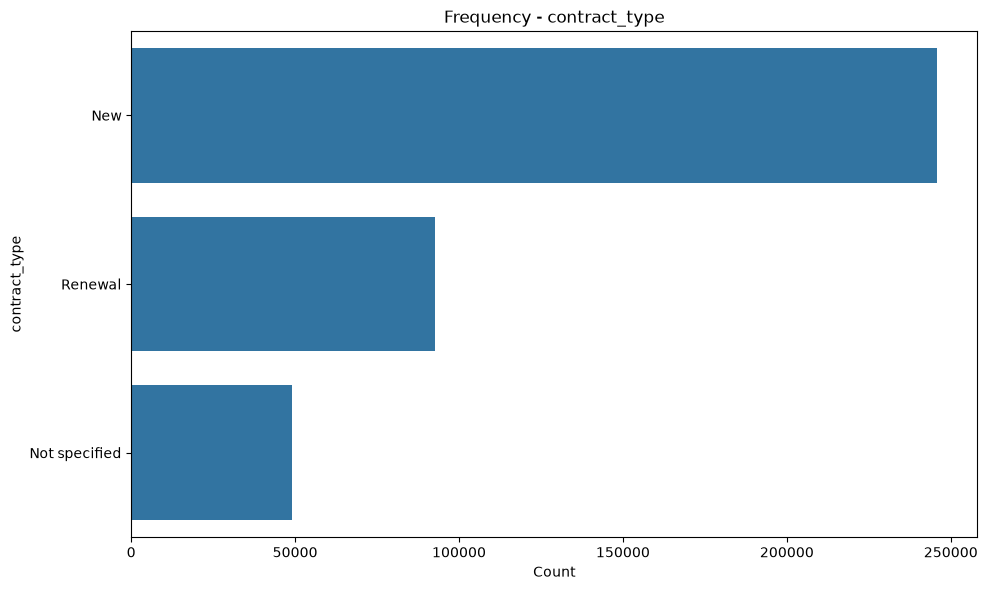

In [67]:
contract_type_summary = analyze_categorical(df_copy, 'contract_type')

--- renewal_right_used ---
                     count  percentage
renewal_right_used                    
No/Not reported     351610       90.78
Yes                  35716        9.22


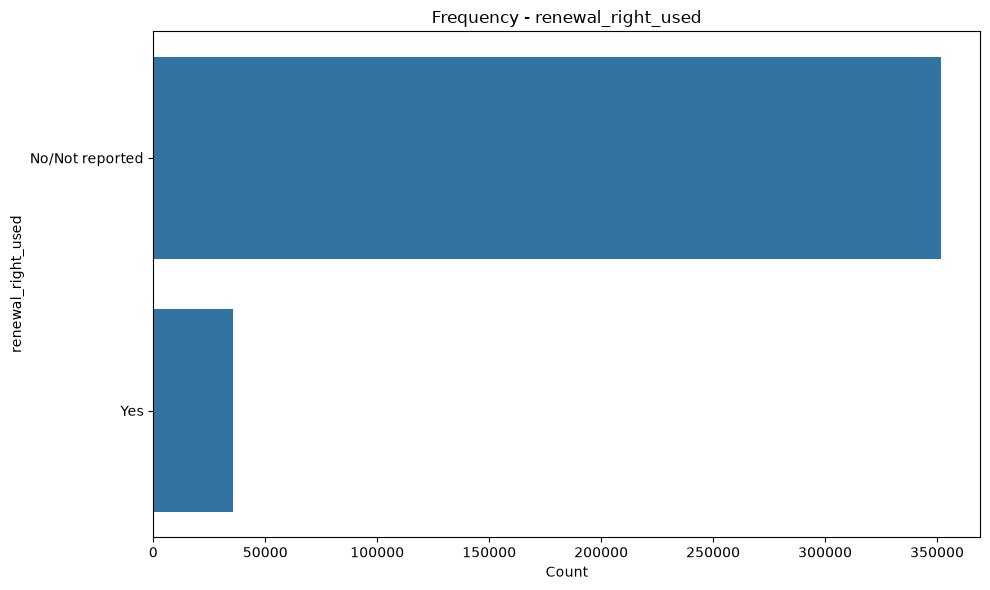

In [68]:
renewal_right_summary = analyze_categorical(df_copy, 'renewal_right_used')

## **6: Bivariate analysis**

Now let's compare the **deposit_10k_krw** field with other fields to see if there is a correlation between this field and another one

### **`deposit_10k_krw` vs. `district_name`**

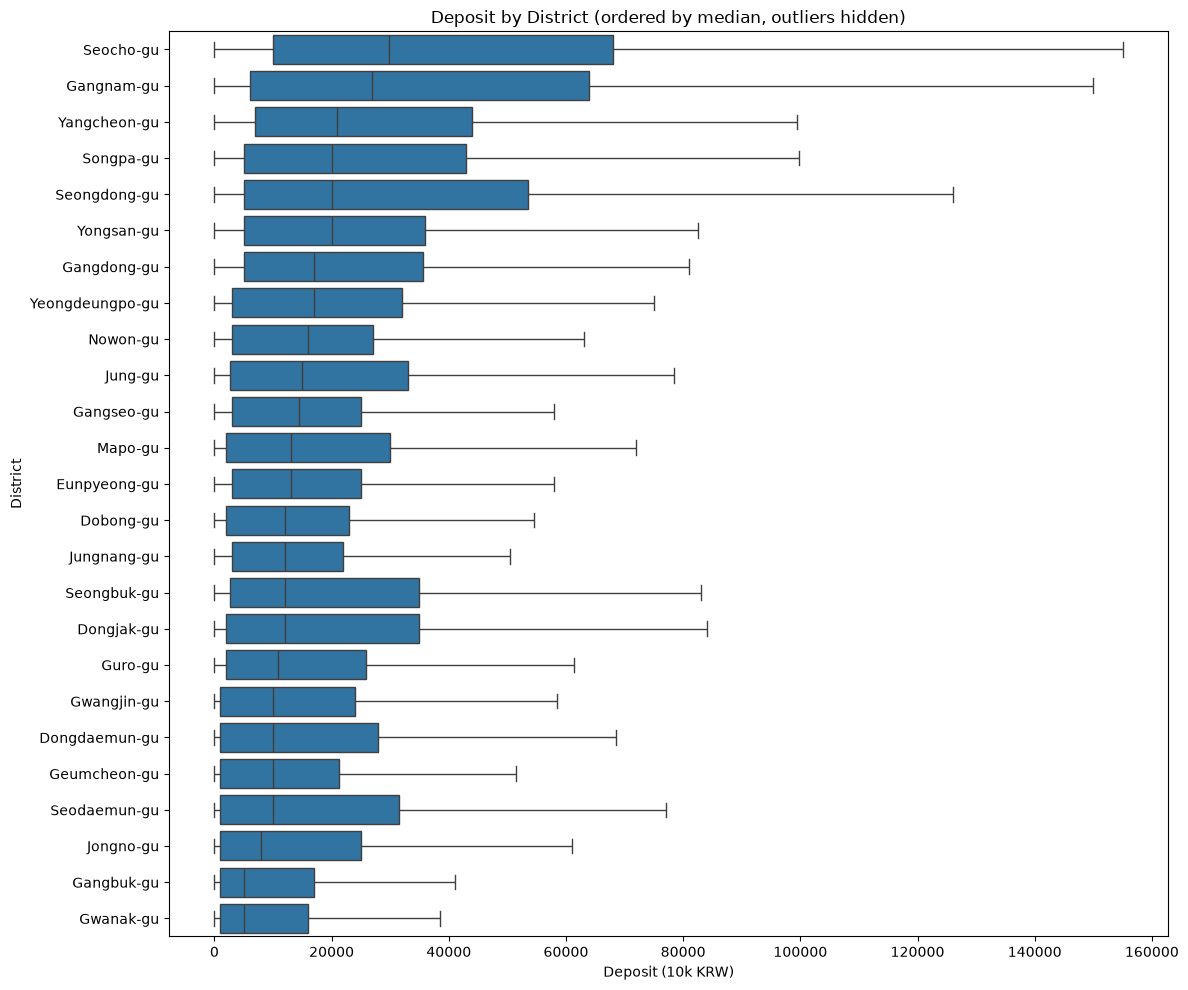

In [69]:
plt.figure(figsize=(12, 10))
order = df_copy.groupby('district_name')['deposit_10k_krw'].median().sort_values(ascending=False).index
sns.boxplot(data=df_copy, x='deposit_10k_krw', y='district_name', order=order, showfliers=False)
plt.title('Deposit by District (ordered by median, outliers hidden)')
plt.xlabel('Deposit (10k KRW)')
plt.ylabel('District')
plt.tight_layout()
plt.show()

### **`deposit_10k_krw` vs. `leased_area_sqm`**

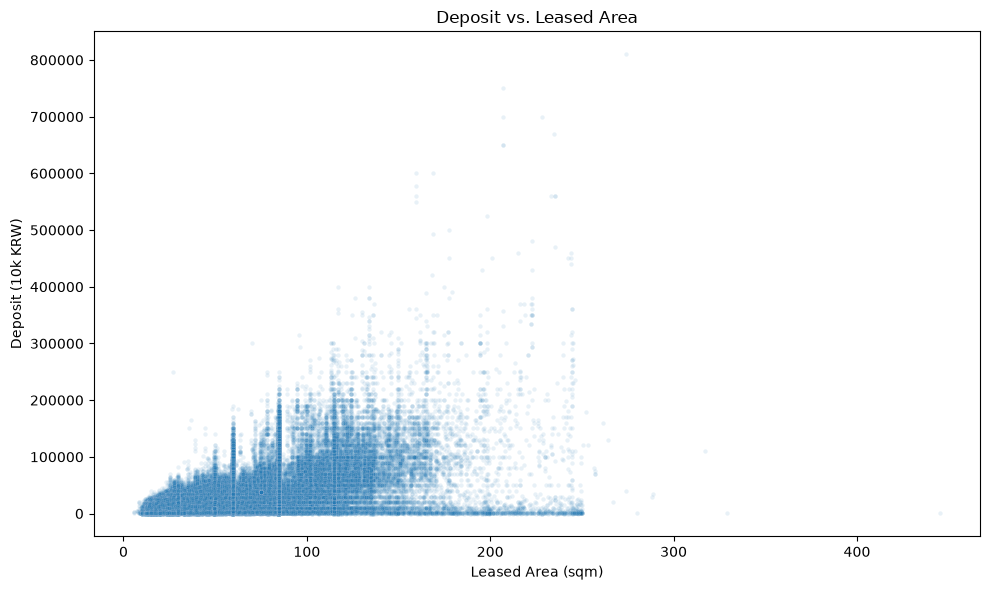

Correlation (leased_area_sqm vs deposit_10k_krw): 0.636


In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='leased_area_sqm', y='deposit_10k_krw', alpha=0.1, s=10)
plt.title('Deposit vs. Leased Area')
plt.xlabel('Leased Area (sqm)')
plt.ylabel('Deposit (10k KRW)')
plt.tight_layout()
plt.show()

correlation = df_copy[['leased_area_sqm', 'deposit_10k_krw']].corr().iloc[0, 1]
print(f"Correlation (leased_area_sqm vs deposit_10k_krw): {correlation:.3f}")

### **`deposit_10k_krw` vs. `building_type`**

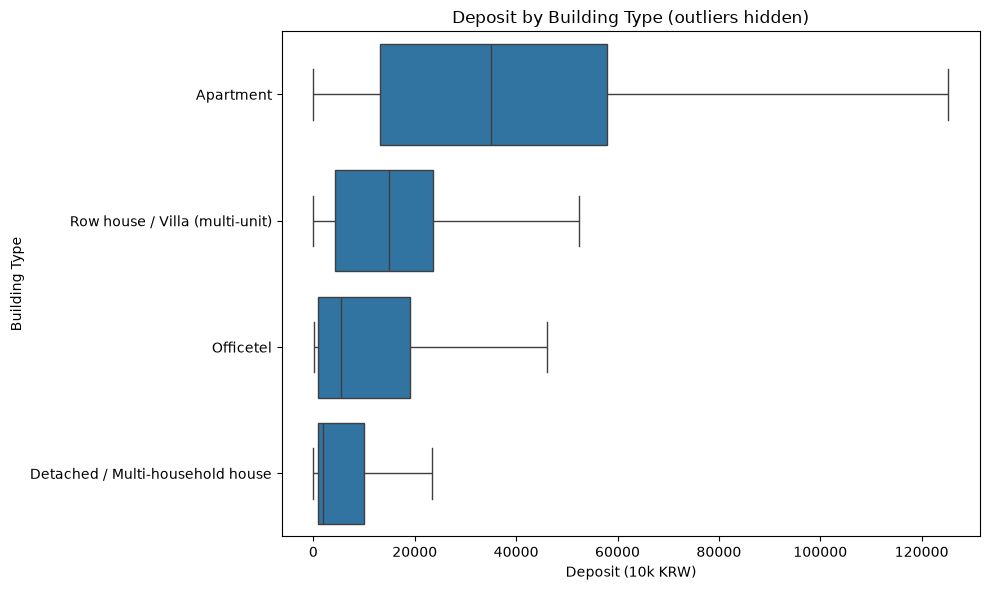

In [71]:
plt.figure(figsize=(10, 6))
order = df_copy.groupby('building_type')['deposit_10k_krw'].median().sort_values(ascending=False).index
sns.boxplot(data=df_copy, x='deposit_10k_krw', y='building_type', order=order, showfliers=False)
plt.title('Deposit by Building Type (outliers hidden)')
plt.xlabel('Deposit (10k KRW)')
plt.ylabel('Building Type')
plt.tight_layout()
plt.show()

In [72]:
median_by_type = df_copy.groupby(['building_type', 'lease_type'])['deposit_10k_krw'].median().unstack()
median_by_type['Pooled'] = df_copy.groupby('building_type')['deposit_10k_krw'].median()
display(median_by_type.sort_values('Pooled', ascending=False))

lease_type,Jeonse (deposit only),Monthly rent,Pooled
building_type,,,
Apartment,50000.0,10000.0,35000.0
Row house / Villa (multi-unit),22000.0,4500.0,15000.0
Officetel,21000.0,1000.0,5500.0
Detached / Multi-household house,12000.0,1000.0,2000.0


### **`deposit_10k_krw` vs. `floor`**

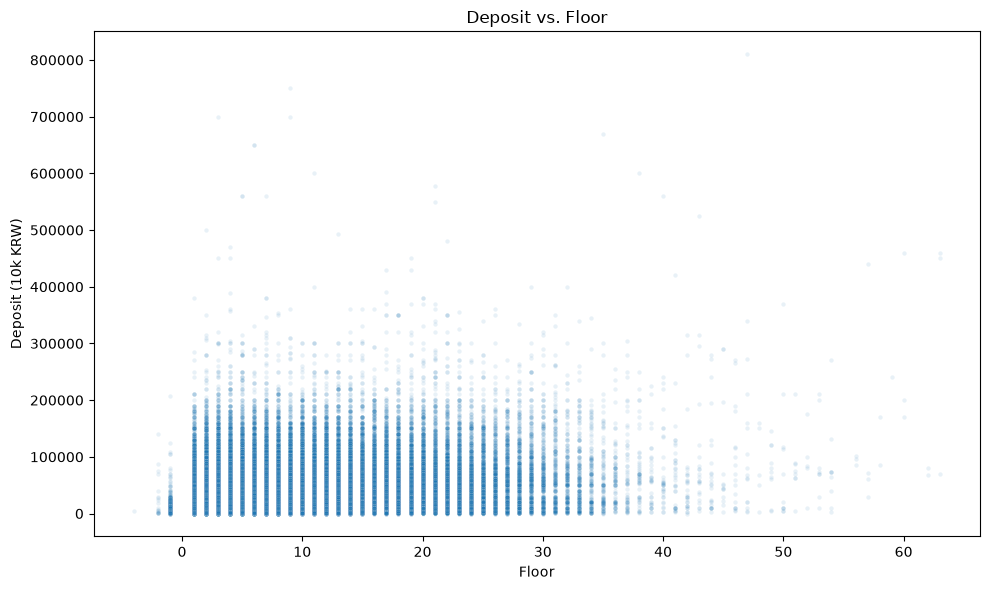

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='floor', y='deposit_10k_krw', alpha=0.1, s=10)
plt.title('Deposit vs. Floor')
plt.xlabel('Floor')
plt.ylabel('Deposit (10k KRW)')
plt.tight_layout()
plt.show()

### **`deposit_10k_krw` vs. `year_built`**

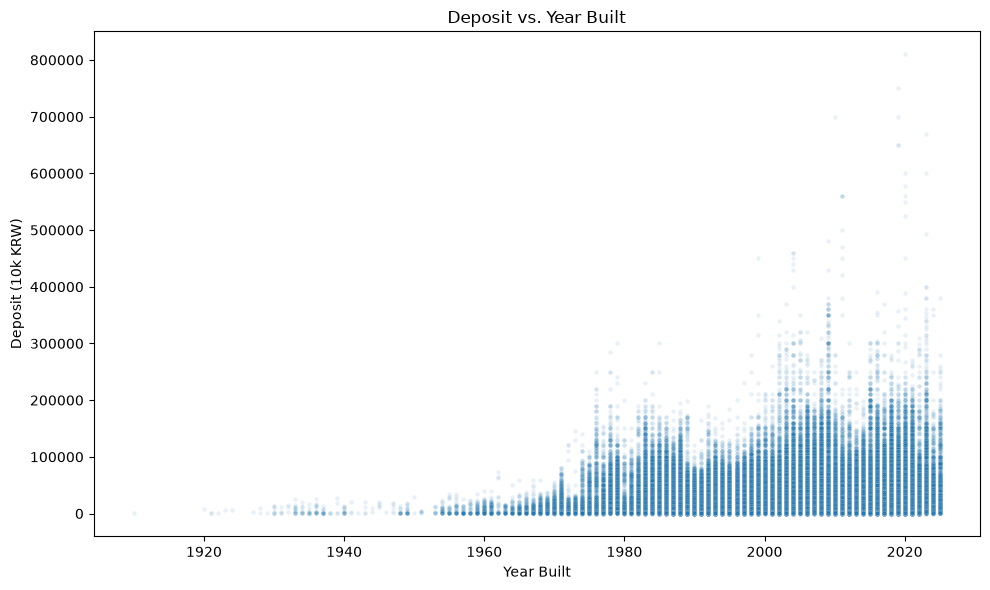

In [74]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='year_built', y='deposit_10k_krw', alpha=0.1, s=10)
plt.title('Deposit vs. Year Built')
plt.xlabel('Year Built')
plt.ylabel('Deposit (10k KRW)')
plt.tight_layout()
plt.show()

In [75]:
by_decade = df_copy.groupby(df_copy['year_built'] // 10 * 10)['deposit_10k_krw'].agg(records='size', median='median', maximum='max')
by_decade.index = by_decade.index.astype(int)
display(by_decade)

,records,median,maximum
year_built,,,
1910,1,1000.0,1000
1920,10,2250.0,10500
1930,83,2000.0,28000
1940,67,2000.0,21000
1950,235,2800.0,35000
1960,1386,3000.0,74000
1970,8342,13000.0,300000
1980,37786,15000.0,300000
1990,83100,10000.0,450000


### **`lease_type` vs. `district_name`**

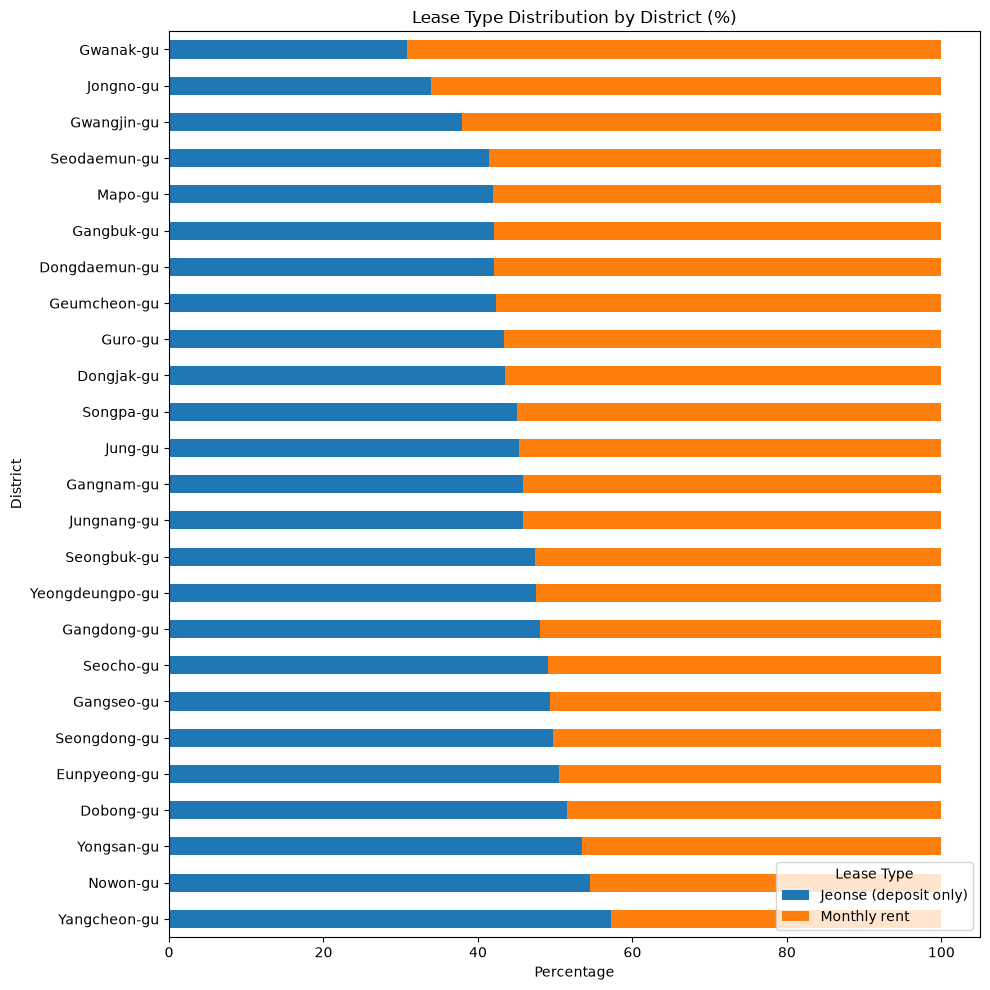

In [76]:
crosstab = pd.crosstab(df_copy['district_name'], df_copy['lease_type'], normalize='index') * 100
crosstab = crosstab.sort_values(by='Jeonse (deposit only)', ascending=False)

crosstab.plot(kind='barh', stacked=True, figsize=(10, 10))
plt.title('Lease Type Distribution by District (%)')
plt.xlabel('Percentage')
plt.ylabel('District')
plt.legend(title='Lease Type', loc='lower right')
plt.tight_layout()
plt.show()

In [77]:
jeonse_share = (pd.crosstab(df_copy['district_name'], df_copy['lease_type'], normalize='index')['Jeonse (deposit only)'] * 100).round(2)
jeonse_share = jeonse_share.sort_values(ascending=False)
print(f"Highest Jeonse share: {jeonse_share.idxmax()} ({jeonse_share.max():.2f}%)")
print(f"Lowest Jeonse share: {jeonse_share.idxmin()} ({jeonse_share.min():.2f}%)")

pooled_median = df_copy.groupby('district_name')['deposit_10k_krw'].median().sort_values()
print(f"Lowest pooled median deposit: {pooled_median.index[0]} ({pooled_median.iloc[0]:,.0f}) | highest: {pooled_median.index[-1]} ({pooled_median.iloc[-1]:,.0f})")
display(jeonse_share.to_frame('jeonse_pct'))

Highest Jeonse share: Yangcheon-gu (57.26%)
Lowest Jeonse share: Gwanak-gu (30.77%)
Lowest pooled median deposit: Gangbuk-gu (5,000) | highest: Seocho-gu (29,725)


,jeonse_pct
district_name,
Yangcheon-gu,57.26
Nowon-gu,54.46
Yongsan-gu,53.45
Dobong-gu,51.50
Eunpyeong-gu,50.43
Seongdong-gu,49.72
Gangseo-gu,49.31
Seocho-gu,49.05
Gangdong-gu,48.05


## **7: Correlation analysis**

This section measures how strongly the numeric variables move together. Two coefficients are used:

- **Pearson**: measures *linear* association and is sensitive to extreme values.
- **Spearman**: measures *monotonic* association using ranks, so it is robust to outliers and skewed distributions, both present in this dataset.

As a rule of thumb, |r| < 0.3 is considered weak, 0.3–0.7 moderate and > 0.7 strong. The first heatmaps use `deposit_10k_krw`, `leased_area_sqm`, `floor` and `year_built`. `monthly_rent_10k_krw` is analyzed separately on Wolse contracts, because it equals 0 for every Jeonse contract.

Pearson correlation (all contracts)


,deposit_10k_krw,leased_area_sqm,floor,year_built
deposit_10k_krw,1.000,0.636,0.267,0.053
leased_area_sqm,0.636,1.000,0.205,-0.235
floor,0.267,0.205,1.000,0.111
year_built,0.053,-0.235,0.111,1.000


Spearman correlation (all contracts)


,deposit_10k_krw,leased_area_sqm,floor,year_built
deposit_10k_krw,1.000,0.647,0.192,0.072
leased_area_sqm,0.647,1.000,0.158,-0.273
floor,0.192,0.158,1.000,0.117
year_built,0.072,-0.273,0.117,1.000


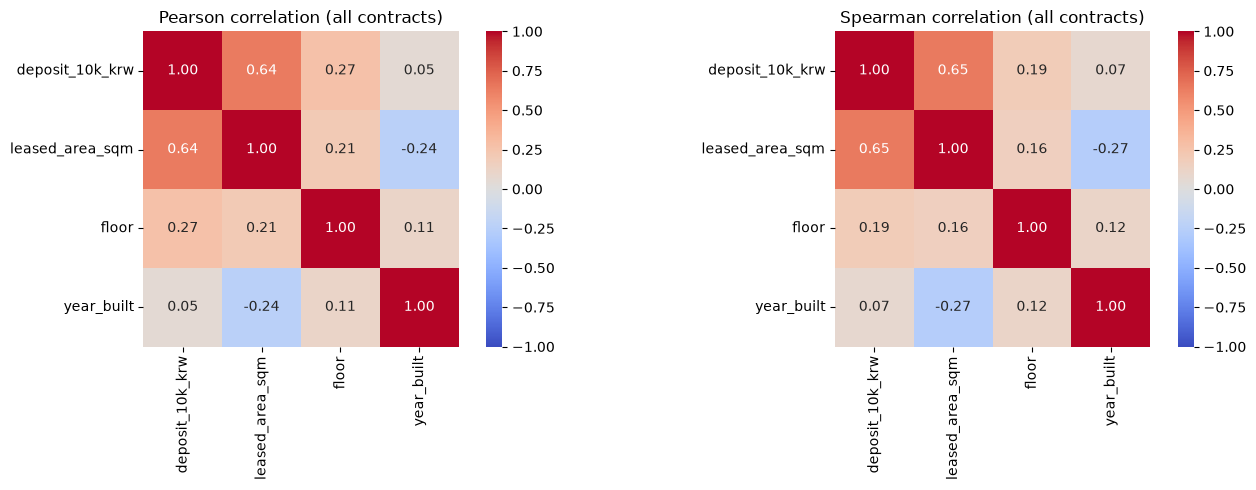

In [78]:
corr_cols = ['deposit_10k_krw', 'leased_area_sqm', 'floor', 'year_built']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, method in zip(axes, ['pearson', 'spearman']):
    corr = df_copy[corr_cols].corr(method=method)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title(f'{method.capitalize()} correlation (all contracts)')
    print(f'{method.capitalize()} correlation (all contracts)')
    display(corr.round(3))
plt.tight_layout()
plt.show()

**Interpretation (all contracts).** The variable most associated with `deposit_10k_krw` is `leased_area_sqm`, with a moderate positive correlation (Pearson = 0.636, Spearman = 0.647). `floor` shows a weak positive correlation (Spearman = 0.192) and `year_built` practically none (Spearman = 0.072).

Pearson and Spearman are almost identical for the deposit–area pair, so this relationship is not driven by extreme values. For `floor`, Pearson (0.267) is higher than Spearman (0.192), which suggests that a few very high floors with very high deposits inflate the linear coefficient.

`year_built` is negatively correlated with `leased_area_sqm` (Spearman = −0.273): newer buildings tend to have smaller units. This may offset the premium that newer buildings carry, which would explain why construction year shows almost no overall association with deposit despite the higher deposit ceiling in newer buildings (maximum deposit of 300,000 for buildings from the 1980s against 810,000 for buildings from the 2020s).

Spearman correlation (Monthly rent contracts only)


,monthly_rent_10k_krw,deposit_10k_krw,leased_area_sqm,floor,year_built
monthly_rent_10k_krw,1.000,0.005,0.336,0.198,0.039
deposit_10k_krw,0.005,1.000,0.547,0.138,0.172
leased_area_sqm,0.336,0.547,1.000,0.088,-0.265
floor,0.198,0.138,0.088,1.000,0.176
year_built,0.039,0.172,-0.265,0.176,1.000


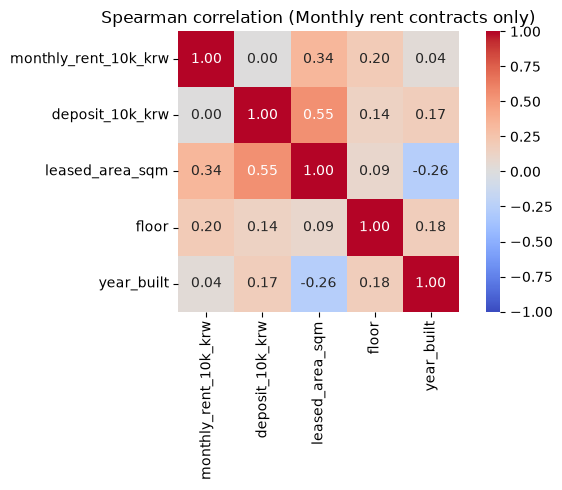

In [79]:
corr_cols_wolse = ['monthly_rent_10k_krw', 'deposit_10k_krw', 'leased_area_sqm', 'floor', 'year_built']
wolse_corr = df_wolse[corr_cols_wolse].corr(method='spearman')
print('Spearman correlation (Monthly rent contracts only)')
display(wolse_corr.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(wolse_corr, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Spearman correlation (Monthly rent contracts only)')
plt.tight_layout()
plt.show()

**Interpretation (Wolse contracts).** Among Monthly rent contracts, `monthly_rent_10k_krw` is most associated with `leased_area_sqm` (Spearman = 0.336, moderate and close to the lower limit of that range), followed by `floor` (0.198, weak). Its correlation with `year_built` is negligible (0.039).

The correlation between monthly rent and deposit is practically zero (Spearman = 0.005): contracts with a larger deposit do not systematically pay a higher or lower monthly rent. This is consistent with a deposit–rent trade-off in the Korean Wolse market, where the same property can be rented with a high deposit and a low rent or the opposite, although this dataset alone cannot confirm that mechanism. Deposit is moderately associated with area within Wolse contracts (0.547).

In [80]:
for lease, group in df_copy.groupby('lease_type'):
    r = group['deposit_10k_krw'].corr(group['leased_area_sqm'], method='spearman')
    print(f"{lease}: Spearman(deposit, area) = {r:.3f}")

Jeonse (deposit only): Spearman(deposit, area) = 0.749
Monthly rent: Spearman(deposit, area) = 0.547


**Area vs. deposit by lease type.** The Spearman correlation between `leased_area_sqm` and `deposit_10k_krw` is 0.749 for Jeonse and 0.547 for Monthly rent, compared with 0.636 (Pearson) and 0.647 (Spearman) on the pooled data. Area is therefore a stronger signal of price in Jeonse contracts, and pooling both types dilutes the relationship. For this reason `lease_type` will be considered explicitly in the modeling phase, either as a feature or by fitting separate models.

In [81]:
corr = df_copy[corr_cols].corr(method='spearman')
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().rename('corr').reset_index()
pairs[pairs['corr'].abs() > 0.7]

,level_0,level_1,corr


**Multicollinearity check.** No pair of numeric variables exceeds |0.7| (Spearman), so multicollinearity is not a concern at this stage. The strongest pair is `deposit_10k_krw` – `leased_area_sqm` (0.647), and among the predictors the largest association is `leased_area_sqm` – `year_built` (−0.273). VIF will be re-checked during feature engineering once new variables are created.

## **8: Temporal and geographic analysis**

### **Evolution over time**

`contract_date` was converted to a datetime and aggregated by month. Jeonse deposits and Wolse monthly rents are analyzed separately, using the **median** because both variables are strongly right-skewed.

Three limitations apply:
- The dataset is a sample with about 100,000 records per year in the original files (2022–2025), so the **absolute number of contracts per month or per year does not represent real market volume** and is not comparable across years; only relative differences between months are informative.
- January 2026 contained only 11 records, so it was removed in the cleaning section to avoid a misleading last data point.
- A change in the median can also be caused by a change in the mix of districts or unit sizes, which is why the Jeonse trend is also checked per square meter.

In [82]:
# Check coverage first: partial months/years at the edges were removed in the cleaning section
monthly_counts = df_copy['contract_month'].value_counts().sort_index()
print(f"Records per month: min {monthly_counts.min():,} ({monthly_counts.idxmin():%Y-%m}), max {monthly_counts.max():,} ({monthly_counts.idxmax():%Y-%m})")
for year, counts in monthly_counts.groupby(monthly_counts.index.year):
    print(f"{year}: peak month {counts.idxmax():%Y-%m} ({counts.max():,}), lowest month {counts.idxmin():%Y-%m} ({counts.min():,})")
monthly_counts

Records per month: min 6,222 (2025-12), max 10,049 (2022-02)
2022: peak month 2022-02 (10,049), lowest month 2022-11 (6,678)
2023: peak month 2023-02 (9,569), lowest month 2023-09 (7,341)
2024: peak month 2024-01 (9,048), lowest month 2024-09 (6,654)
2025: peak month 2025-02 (9,780), lowest month 2025-12 (6,222)


contract_month
2022-01-01     9562
2022-02-01    10049
2022-03-01     9629
2022-04-01     9009
2022-05-01     8885
2022-06-01     8283
2022-07-01     8969
2022-08-01     8072
2022-09-01     7430
2022-10-01     7178
2022-11-01     6678
2022-12-01     7443
2023-01-01     7691
2023-02-01     9569
2023-03-01     9191
2023-04-01     8176
2023-05-01     8279
2023-06-01     8021
2023-07-01     8012
2023-08-01     7832
2023-09-01     7341
2023-10-01     8332
2023-11-01     7832
2023-12-01     8559
2024-01-01     9048
2024-02-01     6691
2024-03-01     7250
2024-04-01     6812
2024-05-01     7942
2024-06-01     7851
2024-07-01     8156
2024-08-01     8176
2024-09-01     6654
2024-10-01     7932
2024-11-01     7286
2024-12-01     7742
2025-01-01     8010
2025-02-01     9780
2025-03-01     8973
2025-04-01     7971
2025-05-01     8303
2025-06-01     8351
2025-07-01     8250
2025-08-01     7955
2025-09-01     7374
2025-10-01     7025
2025-11-01     7550
2025-12-01     6222
Name: count, dtype: int64

**Contract activity by month.** The number of records per month ranges from 6,222 (December 2025) to 10,049 (February 2022). Each year peaks in the first two months: February 2022 (10,049), February 2023 (9,569), January 2024 (9,048) and February 2025 (9,780). This is consistent with the typical winter–spring moving season in Korea. The lowest month of each year is November 2022 (6,678), September 2023 (7,341), September 2024 (6,654) and December 2025 (6,222); the low value of December 2025 may be due to contracts not yet registered at the time of extraction. October 2022 (7,178) does not stand out from its neighbors. The original sample contains about 100,000 records for each of 2022–2025, so counts are not comparable across years: the yearly totals below (from 91,540 to 101,187) reflect the sampling and the cleaning, not market growth.

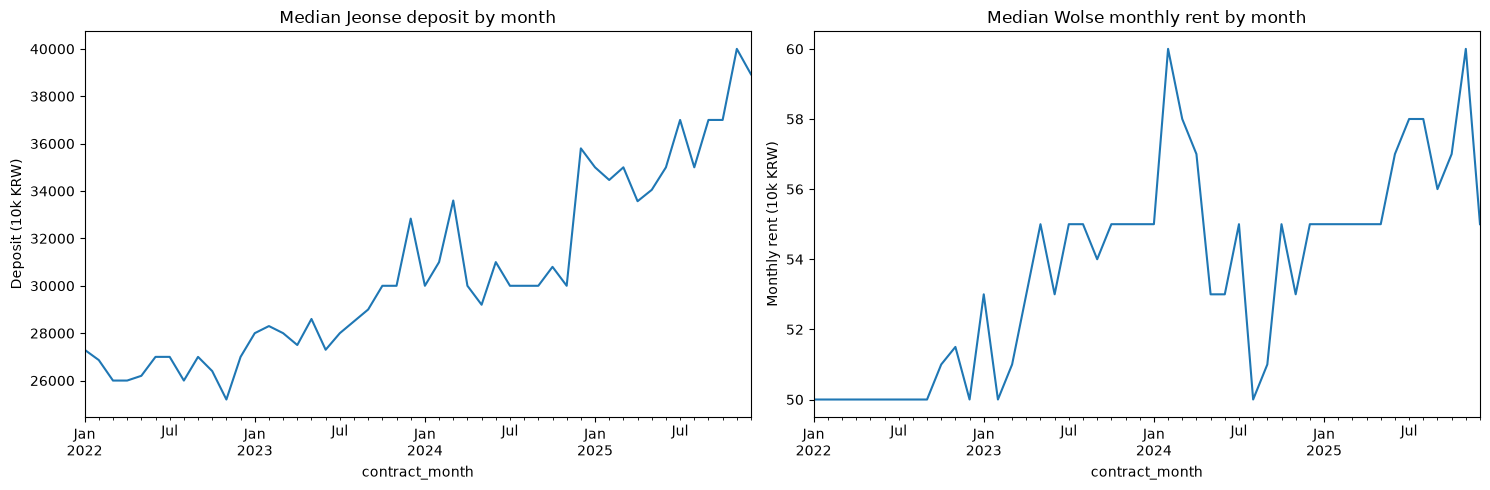

In [83]:
df_jeonse = df_copy[df_copy['lease_type'] == 'Jeonse (deposit only)']
df_wolse = df_copy[df_copy['lease_type'] == 'Monthly rent']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_jeonse.groupby('contract_month')['deposit_10k_krw'].median().plot(ax=axes[0])
axes[0].set_title('Median Jeonse deposit by month')
axes[0].set_ylabel('Deposit (10k KRW)')

df_wolse.groupby('contract_month')['monthly_rent_10k_krw'].median().plot(ax=axes[1])
axes[1].set_title('Median Wolse monthly rent by month')
axes[1].set_ylabel('Monthly rent (10k KRW)')
plt.tight_layout()
plt.show()

**Interpretation.** The median Jeonse deposit shows a clear upward trend. By contract year it rises from 26,319 (2022) to 28,850 (2023), 30,462.5 (2024) and 35,500 (2025), in 10k KRW, a total increase of 34.88% between 2022 and 2025. The largest yearly step is 2025 (+16.54%), after +9.62% in 2023 and +5.59% in 2024 (yearly table below). At the monthly level the median ranges from 25,200 (November 2022) to 40,000 (November 2025).

The median Wolse monthly rent rises more modestly: from 50 (2022) to 54 (2023) and 55 in both 2024 and 2025 (10k KRW, i.e. 500,000–550,000 KRW), a total increase of 10.00%. The monthly medians stay between 50 and 60. Because rents are usually set in round amounts, the median moves in coarse steps and is a blunt indicator; the mean, upper quartiles or rent per sqm would be more sensitive to small changes.

In this sample, the increase in the median is therefore much larger for Jeonse deposits than for Wolse rents, but part of the Jeonse increase reflects larger units, as the per-square-meter analysis below shows.

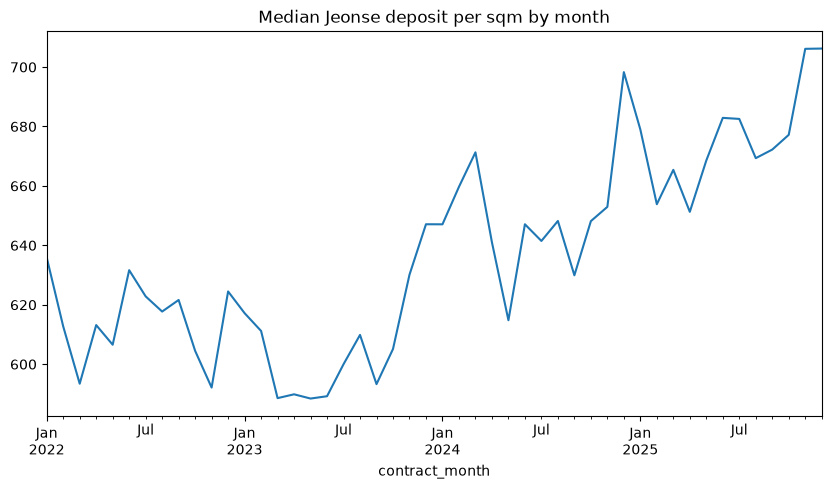

In [84]:
df_jeonse = df_jeonse.assign(deposit_per_sqm=df_jeonse['deposit_10k_krw'] / df_jeonse['leased_area_sqm'])
df_jeonse.groupby('contract_month')['deposit_per_sqm'].median().plot(figsize=(10, 5), title='Median Jeonse deposit per sqm by month')
plt.show()

In [85]:
jeonse_year = df_jeonse['contract_date'].dt.year
wolse_year = df_wolse['contract_date'].dt.year

yearly = pd.DataFrame({
    'jeonse_records': df_jeonse.groupby(jeonse_year).size(),
    'median_jeonse_deposit': df_jeonse.groupby(jeonse_year)['deposit_10k_krw'].median(),
    'median_jeonse_deposit_per_sqm': df_jeonse.groupby(jeonse_year)['deposit_per_sqm'].median(),
    'median_jeonse_area_sqm': df_jeonse.groupby(jeonse_year)['leased_area_sqm'].median(),
    'wolse_records': df_wolse.groupby(wolse_year).size(),
    'median_wolse_rent': df_wolse.groupby(wolse_year)['monthly_rent_10k_krw'].median(),
})
yearly.index.name = 'contract_year'
yearly['total_records'] = yearly['jeonse_records'] + yearly['wolse_records']
yearly['deposit_change_pct'] = yearly['median_jeonse_deposit'].pct_change() * 100
yearly['deposit_per_sqm_change_pct'] = yearly['median_jeonse_deposit_per_sqm'].pct_change() * 100
yearly['wolse_rent_change_pct'] = yearly['median_wolse_rent'].pct_change() * 100
display(yearly.round(2))

first, last = yearly.index[0], yearly.index[-1]
total_change = (yearly.loc[last] / yearly.loc[first] - 1) * 100
print(f"Change {first} -> {last}: median Jeonse deposit {total_change['median_jeonse_deposit']:+.2f}%, "
      f"deposit per sqm {total_change['median_jeonse_deposit_per_sqm']:+.2f}%, "
      f"Jeonse area {total_change['median_jeonse_area_sqm']:+.2f}%, Wolse rent {total_change['median_wolse_rent']:+.2f}%")

monthly_deposit = df_jeonse.groupby('contract_month')['deposit_10k_krw'].median()
print(f"Monthly median Jeonse deposit: min {monthly_deposit.min():,.0f} ({monthly_deposit.idxmin():%Y-%m}), max {monthly_deposit.max():,.0f} ({monthly_deposit.idxmax():%Y-%m})")
monthly_rent = df_wolse.groupby('contract_month')['monthly_rent_10k_krw'].median()
print(f"Monthly median Wolse rent: min {monthly_rent.min():,.0f}, max {monthly_rent.max():,.0f}")

,jeonse_records,median_jeonse_deposit,median_jeonse_deposit_per_sqm,median_jeonse_area_sqm,wolse_records,median_wolse_rent,total_records,deposit_change_pct,deposit_per_sqm_change_pct,wolse_rent_change_pct
contract_year,,,,,,,,,,
2022,50327,26319.0,615.38,50.68,50860,50.0,101187,NaN,NaN,NaN
2023,47513,28850.0,604.59,59.11,51322,54.0,98835,9.62,-1.75,8.00
2024,41008,30462.5,649.40,59.38,50532,55.0,91540,5.59,7.41,1.85
2025,37935,35500.0,673.85,59.86,57829,55.0,95764,16.54,3.77,0.00


Change 2022 -> 2025: median Jeonse deposit +34.88%, deposit per sqm +9.50%, Jeonse area +18.11%, Wolse rent +10.00%
Monthly median Jeonse deposit: min 25,200 (2022-11), max 40,000 (2025-11)
Monthly median Wolse rent: min 50, max 60


**Deposit per square meter.** When normalized by area, the upward trend is much milder: the median Jeonse deposit per sqm moves from 615.38 (2022) to 604.59 (2023), 649.40 (2024) and 673.85 (2025) (10k KRW per sqm), an increase of 9.50% between 2022 and 2025 (yearly changes of −1.75%, +7.41% and +3.77%). Over the same period the median Jeonse area grew from 50.68 sqm to 59.86 sqm (+18.11%), mostly between 2022 and 2023 (59.11 sqm). In 2023 the raw median deposit rose by 9.62% while the deposit per sqm fell by 1.75%, so that rise reflects a change in the mix of units rather than a rise in the price per sqm. A large part of the 34.88% rise in the raw median deposit may therefore come from larger units in recent contracts. The yearly table also shows that the number of Jeonse records falls from 50,327 to 37,935 while Wolse records rise from 50,860 to 57,829; these counts describe the sample, not the market.

In [86]:
jeonse_rank = (df_jeonse.groupby('district_name')['deposit_10k_krw']
               .agg(median='median', mean='mean', n='size')
               .sort_values('median', ascending=False))

wolse_rank = (df_wolse.groupby('district_name')
              .agg(median_rent=('monthly_rent_10k_krw', 'median'),
                   median_deposit=('deposit_10k_krw', 'median'),
                   n=('monthly_rent_10k_krw', 'size'))
              .sort_values('median_rent', ascending=False))

display(jeonse_rank.head(5)); display(jeonse_rank.tail(5))
display(wolse_rank.head(5)); display(wolse_rank.tail(5))

,median,mean,n
district_name,,,
Gangnam-gu,54600.0,66947.824038,11457
Seocho-gu,52500.0,69313.017529,9185
Seongdong-gu,50000.0,50296.752914,6091
Songpa-gu,38256.0,48255.911476,14561
Dongjak-gu,35000.0,39821.285813,7218


,median,mean,n
district_name,,,
Jungnang-gu,22000.0,25268.109794,6075
Dobong-gu,21600.0,24130.821369,4165
Geumcheon-gu,20625.0,22997.082913,3968
Gwanak-gu,20500.0,26055.065707,6666
Gangbuk-gu,18000.0,22580.714097,3029


,median_rent,median_deposit,n
district_name,,,
Gangnam-gu,85.0,9468.0,13541
Seocho-gu,77.0,10000.0,9542
Jung-gu,70.0,3000.0,3041
Yongsan-gu,70.0,5000.0,4614
Mapo-gu,62.0,3000.0,11609


,median_rent,median_deposit,n
district_name,,,
Gangdong-gu,47.0,5000.0,10851
Gwanak-gu,47.0,2000.0,14998
Gangbuk-gu,45.0,1000.0,4176
Guro-gu,45.0,3000.0,7814
Jungnang-gu,42.0,3000.0,7170


In [87]:
ratio_rows = []
for market, rank, col in [('Jeonse deposit', jeonse_rank, 'median'), ('Wolse monthly rent', wolse_rank, 'median_rent')]:
    bottom_name = rank[col].idxmin()
    bottom_value = rank.loc[bottom_name, col]
    for district in rank[col].nlargest(3).index:
        ratio_rows.append({
            'market': market,
            'top_district': district,
            'top_median': rank.loc[district, col],
            'bottom_district': bottom_name,
            'bottom_median': bottom_value,
            'ratio': rank.loc[district, col] / bottom_value,
        })
display(pd.DataFrame(ratio_rows).round(2))

,market,top_district,top_median,bottom_district,bottom_median,ratio
0,Jeonse deposit,Gangnam-gu,54600.0,Gangbuk-gu,18000.0,3.03
1,Jeonse deposit,Seocho-gu,52500.0,Gangbuk-gu,18000.0,2.92
2,Jeonse deposit,Seongdong-gu,50000.0,Gangbuk-gu,18000.0,2.78
3,Wolse monthly rent,Gangnam-gu,85.0,Jungnang-gu,42.0,2.02
4,Wolse monthly rent,Seocho-gu,77.0,Jungnang-gu,42.0,1.83
5,Wolse monthly rent,Jung-gu,70.0,Jungnang-gu,42.0,1.67


**Interpretation.** Ranking each lease type separately removes the contract-mix effect seen in the bivariate analysis.

For **Jeonse**, the most expensive districts by median deposit are Gangnam-gu (54,600), Seocho-gu (52,500), Seongdong-gu (50,000), Songpa-gu (38,256) and Dongjak-gu (35,000), all in 10k KRW. The cheapest are Gangbuk-gu (18,000), Gwanak-gu (20,500), Geumcheon-gu (20,625), Dobong-gu (21,600) and Jungnang-gu (22,000). The median deposit in Gangnam-gu is 3.03 times that of Gangbuk-gu. Pooled medians are not comparable across districts because they depend on the Jeonse share, which ranges from 30.77% (Gwanak-gu) to 57.26% (Yangcheon-gu): the lowest pooled median belongs to Gangbuk-gu (5,000), far below its Jeonse median (18,000), because its Wolse contracts have a median deposit of only 1,000.

For **Wolse**, the highest median monthly rents are in Gangnam-gu (85), Seocho-gu (77), Jung-gu and Yongsan-gu (70 each) and Mapo-gu (62), while the lowest are Jungnang-gu (42), Gangbuk-gu and Guro-gu (45 each) and Gangdong-gu and Gwanak-gu (47 each). The ratio between the highest and the lowest district is 2.02 (Gangnam-gu vs. Jungnang-gu), lower than the 3.03 of Jeonse. Since several districts share the same median, the lower ranks are not a strict ranking.

Gangnam-gu and Seocho-gu are the most expensive in both markets (ratios to the cheapest district: 3.03 and 2.92 for Jeonse, 2.02 and 1.83 for Wolse). Jung-gu and Yongsan-gu, in contrast, are among the most expensive for Wolse rent but do not appear in the Jeonse top five, which suggests that central districts are comparatively costly for monthly renters. Every district shown in both rankings has more than 3,000 records, so the medians are reasonably reliable.

### **Foreigner- and student-oriented areas**

Three well-known areas are compared with the rest of Seoul: **Sinchon** (Seodaemun-gu), **Hongdae** (Mapo-gu) and **Itaewon** (Yongsan-gu). The dataset records legal neighborhoods (법정동) rather than popular area names, so each area is approximated by the legal dongs that cover it:
- Sinchon: Sinchon-dong and Changcheon-dong
- Hongdae: Seogyo-dong, Donggyo-dong, Yeonnam-dong and Sangsu-dong
- Itaewon: Itaewon-dong and Hannam-dong

The results should therefore be read as an approximation. For each area, the median deposit, monthly rent, unit size and building type mix are compared with the rest of the city. Sample sizes are much smaller than in the district rankings (216 to 2,078 records per area and lease type), so differences should be interpreted with caution.

In [88]:
zones = {
    'Sinchon': ('Seodaemun-gu', ['Sinchon-dong', 'Changcheon-dong']),
    'Hongdae': ('Mapo-gu', ['Seogyo-dong', 'Donggyo-dong', 'Yeonnam-dong', 'Sangsu-dong']),
    'Itaewon': ('Yongsan-gu', ['Itaewon-dong', 'Hannam-dong']),
}

# Verify the names exist in the data
for zone, (gu, dongs) in zones.items():
    found = df_copy.loc[df_copy['district_name'] == gu, 'legal_dong_name'].unique()
    matched = [d for d in dongs if any(f.startswith(d) for f in found)]
    print(zone, '| matched:', matched, '| missing:', [d for d in dongs if d not in matched])

Sinchon | matched: ['Sinchon-dong', 'Changcheon-dong'] | missing: []
Hongdae | matched: ['Seogyo-dong', 'Donggyo-dong', 'Yeonnam-dong', 'Sangsu-dong'] | missing: []
Itaewon | matched: ['Itaewon-dong', 'Hannam-dong'] | missing: []


In [89]:
df_copy['zone'] = 'Rest of Seoul'
for zone, (gu, dongs) in zones.items():
    mask = (df_copy['district_name'] == gu) & df_copy['legal_dong_name'].str.startswith(tuple(dongs))
    df_copy.loc[mask, 'zone'] = zone

zone_summary = (df_copy.groupby(['zone', 'lease_type'])
                .agg(n=('deposit_10k_krw', 'size'),
                     median_deposit=('deposit_10k_krw', 'median'),
                     median_rent=('monthly_rent_10k_krw', 'median'),
                     median_area=('leased_area_sqm', 'median')))
display(zone_summary)

# Building type mix per zone (officetel share matters for short stays)
display((pd.crosstab(df_copy['zone'], df_copy['building_type'], normalize='index') * 100).round(1))

n  median_deposit  median_rent  \
zone          lease_type                                                   
Hongdae       Jeonse (deposit only)     691         24000.0          0.0   
              Monthly rent             2078          2000.0         60.0   
Itaewon       Jeonse (deposit only)     508         36375.0          0.0   
              Monthly rent              706          2000.0        100.0   
Rest of Seoul Jeonse (deposit only)  175368         30000.0          0.0   
              Monthly rent           206778          3000.0         53.0   
Sinchon       Jeonse (deposit only)     216         14000.0          0.0   
              Monthly rent              981          1000.0         55.0   

                                     median_area  
zone          lease_type                          
Hongdae       Jeonse (deposit only)      40.0000  
              Monthly rent               29.5700  
Itaewon       Jeonse (deposit only)      59.9200  
              Monthly rent               51.8950  
Rest of Seoul Jeonse (deposit only)      58.9015  
              Monthly rent               34.6400  
Sinchon       Jeonse (deposit only)      23.2200  
              Monthly rent               20.0000

building_type,Apartment,Detached / Multi-household house,Officetel,Row house / Villa (multi-unit)
zone,,,,
Hongdae,14.6,37.7,5.5,42.2
Itaewon,32.5,37.5,0.2,29.7
Rest of Seoul,42.2,22.8,12.9,22.1
Sinchon,5.3,57.9,13.0,23.8


**Interpretation (Wolse).** Itaewon is by far the most expensive of the three areas for monthly rent: its median is 100 (10k KRW, i.e. 1,000,000 KRW) versus 53 in the rest of Seoul, with larger units (median 51.9 sqm vs. 34.6 sqm). Hongdae (60) and Sinchon (55) are above the rest-of-Seoul median, but their units are considerably smaller (29.6 sqm and 20.0 sqm vs. 34.6 sqm), so the price per sqm is higher than the raw rent suggests. Median deposits in the three areas are low (1,000–2,000 vs. 3,000 elsewhere), meaning that a Wolse contract in these areas typically requires little upfront capital.

**Interpretation (Jeonse).** Jeonse deposits are below the rest-of-Seoul median (30,000) in Hongdae (24,000) and especially in Sinchon (14,000, with very small units of 23.2 sqm), while Itaewon is higher (36,375) with units similar in size to the rest of Seoul (59.9 sqm vs. 58.9 sqm). The Sinchon Jeonse figure rests on only 216 records.

**Building type.** Officetels, often assumed to be the typical short-stay option, are scarce in these areas: 0.2% in Itaewon, 5.5% in Hongdae and 13.0% in Sinchon (similar to the 12.9% of the rest of Seoul). Supply is instead dominated by detached/multi-household houses (37.5% in Itaewon, 37.7% in Hongdae, 57.9% in Sinchon) and row houses/villas (42.2% in Hongdae). A newcomer searching only for officetels would therefore exclude most of the supply in these neighborhoods.

## **9: Key EDA Insights**

**1. The sample covers all 25 districts without extreme dominance.** Songpa-gu (8.35%), Gangseo-gu (6.92%) and Gangnam-gu (6.45%) are the most represented, while Jongno-gu (1.31%, 5,056 rows) and Jung-gu (1.44%, 5,564 rows) are the smallest. District comparisons are therefore viable, with more caution for the smallest districts.

**2. Lease types are fairly balanced (54.36% Monthly rent vs. 45.64% Jeonse).** `lease_type` can be used as a classification target without resampling techniques.

**3. Apartments dominate the market (41.81%), followed by Detached / Multi-household houses (23.09%), Row houses / Villas (22.32%) and Officetels (12.78%).** New contracts account for 63.44% of the records, renewals for 23.91% and 12.64% have no contract type specified; 9.22% of contracts used the renewal-request right.

**4. The district ranking must be read per lease type.** The Jeonse share ranges from 30.77% (Gwanak-gu) to 57.26% (Yangcheon-gu). In the pooled analysis, Gangbuk-gu has the lowest median deposit (5,000) and Seocho-gu the highest (29,725). Because Wolse contracts carry smaller deposits by design, pooled rankings partly reflect contract mix. Within Jeonse only, the cheapest districts are Gangbuk-gu (18,000), Gwanak-gu (20,500) and Geumcheon-gu (20,625). The wide range of the Jeonse share also suggests that `district_name` will be a useful predictor for lease type classification.

**5. Gangnam-gu and Seocho-gu are the most expensive in both markets.** Their median Jeonse deposits (54,600 and 52,500) are 3.03 and 2.92 times that of the cheapest district (Gangbuk-gu, 18,000), while their median Wolse rents (85 and 77) are 2.02 and 1.83 times that of the cheapest district (Jungnang-gu, 42). Jung-gu and Yongsan-gu (70 each) are expensive for Wolse rent but not for Jeonse.

**6. Building type is a strong price driver.** The pooled median deposits are 35,000 for Apartments, 15,000 for Row houses / Villas, 5,500 for Officetels and 2,000 for Detached / Multi-household houses. Pooled values mix both contract types: within Jeonse the medians are 50,000, 22,000, 21,000 and 12,000, and within Wolse 10,000, 4,500, 1,000 and 1,000, so Officetels are close to Row houses / Villas in Jeonse (21,000 vs. 22,000).

**7. Leased area is the main numeric driver of deposit, but the relationship is not homoscedastic.** The Spearman correlation is 0.647 overall, 0.749 within Jeonse and 0.547 within Wolse. The scatter plot shows a fan shape: the variance of the deposit grows with area, so a linear model on the raw scale would violate its assumptions. This supports the log transformation planned for the modeling phase. The most frequent areas (rounded to the nearest sqm) are 85 and 60 sqm, consistent with standardized apartment unit sizes.

**8. Floor and construction year add little linear signal.** Their Spearman correlations with deposit are 0.192 and 0.072. Newer buildings have a higher deposit ceiling (maximum deposit of 300,000 for the 1980s against 810,000 for the 2020s), but they also tend to have smaller units (correlation with area = −0.273), which offsets the effect in a simple correlation. One data-entry error (floor 302) was removed.

**9. In Wolse contracts, deposit and monthly rent are practically uncorrelated (Spearman = 0.005).** Monthly rent is mostly associated with area (0.336) and floor (0.198). Deposit and monthly rent should therefore be treated as two distinct targets, not as interchangeable measures of price.

**10. Median prices rose between 2022 and 2025, but a large part of the Jeonse increase reflects larger units.** The median Jeonse deposit rose from 26,319 to 35,500 (+34.88%) while the median Jeonse area rose from 50.68 to 59.86 sqm (+18.11%); per sqm, the increase is +9.50%. The median Wolse rent rose from 50 to 55 (+10.00%), in coarse steps because rents are set in round amounts.

**11. Contract activity peaks in the first two months of each year** (February 2022, February 2023, January 2024 and February 2025), consistent with the winter–spring moving season. Counts are indicative only, since the original sample contains about 100,000 records per year; December 2025 is the lowest month (6,222 records).

**12. Itaewon is the most expensive foreigner-oriented area for monthly rent (median 100 vs. 53 in the rest of Seoul)** and has larger units (51.9 sqm vs. 34.6 sqm). Hongdae (60) and Sinchon (55) are above the rest-of-Seoul median rent but with much smaller units (29.6 and 20.0 sqm). Deposits for Wolse contracts in the three areas are low (1,000–2,000 vs. 3,000 elsewhere).

**13. Officetels are scarce in Sinchon, Hongdae and Itaewon (13.0%, 5.5% and 0.2%).** Supply there is dominated by detached/multi-household houses and row houses/villas, so a search limited to officetels would exclude most of the available housing.

### **Implications for the modeling phase**
- Apply a log transformation to deposit, monthly rent and probably area.
- Model Jeonse and Wolse separately, or include `lease_type` explicitly.
- The main predictors are `district_name`, `building_type` and `leased_area_sqm`, with `floor` and `year_built` as secondary features.
- No pair of numeric predictors exceeds |0.7|, so multicollinearity is not a concern among them.
- The classification target `lease_type` is balanced (54.36% vs. 45.64%), and district, building type and area are the natural candidate predictors.
- `lease_type` was inferred from `monthly_rent == 0` in 2022, 2024 and 2025, so `monthly_rent_10k_krw` and `previous_monthly_rent_10k_krw` (and, carefully, `previous_deposit_10k_krw`) must NOT be used as features to predict `lease_type` (target leakage).

## **10: Limitations**

- **Stratified sample.** The dataset contains about 100,000 records per year (2022–2025), so counts per month, year or district are not market volume and are not comparable across years.
- **Rows lost in cleaning.** 12,674 of the 400,000 rows (3.17%) were removed, leaving 387,326 rows. Almost all of them have a missing `year_built` (12,650 rows in `df`). The loss is not uniform: 89.32% of the Detached / Multi-household houses are retained (89,434 of 100,130), against 96.31% to 99.97% for the other building types, and 92.66% of the 2024 rows against 98.05% to 98.38% for the other years. `contract_start` and `contract_end` are missing for 55,451 and 51,748 rows and are not used in the analysis.
- **Inferred `lease_type`.** The label was inferred from `monthly_rent == 0` in 2022, 2024 and 2025; only 2023 has the original value. Inconsistent rows cannot be detected in those years.
- **Zones approximated by legal dongs.** Sinchon, Hongdae and Itaewon are approximated by legal neighborhoods (법정동) and some area–lease type combinations have few records (216 for Sinchon Jeonse).
- **Possible area inconsistency in multi-household houses.** 86.90% of the 435 rows with an area above 130 sqm and a deposit below 1,000 are Detached / Multi-household houses (23.09% of all rows), so the reported area may be that of the whole building. Three rows of 280–445 sqm have a deposit of only 1,000. No rows were removed.